In [1]:
%load_ext autoreload
%autoreload 2
from utils import *
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM
import numpy as np
import pyreadstat
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import ttest_ind
from statsmodels.formula.api import ols
import pingouin as pg
from  matplotlib import patches

# Task data exploration - RQ1

The following file contains all the data exploration related with Research Question 1.

## Load and prepare data

In [2]:
# Read task data
folder_ks = "processed_participant_data/patient/"
folder_hc = "processed_participant_data/controle/"
ks_data_obj, ks_data_trials = load_data(folder_ks, "KS")
hc_data_obj, hc_data_trials = load_data(folder_hc, "HC")

data_obj = pd.concat([ks_data_obj, hc_data_obj], ignore_index=True)
data_trials = pd.concat([ks_data_trials, hc_data_trials], ignore_index=True)

In [3]:
# Read debestfit_distsmographical data
demographic_df, _ = pyreadstat.read_sav("../../object location data/Definitieve data file Data masterthesis GOED.sav")
covariates = demographic_df[['ID','groep', 'NLV', 'IF_Stroop']].copy()
covariates['groep'] = covariates['groep'].map({0.0: 'KS', 1.0: 'HC'})

data_trials = data_trials.merge(covariates[["ID", "NLV", "IF_Stroop"]],on="ID",how="left")

data_obj.columns = [c.replace(' ', '_') for c in data_obj.columns]
data_trials.columns = [c.replace(' ', '_') for c in data_trials.columns]

In [4]:
# Define condition label mapping (exact names)
condition_labels = { "B": "baseline", "NT": "negative transfer", "SimRI": "similarity RI",
"DivRI": "diversion RI","D": "delay"}

# Define exact plotting order
condition_order = ["B", "NT", "SimRI", "DivRI", "D"]

SCALE = 19 # Scale factor

### Preprocessing - NLV

In [5]:
nlv_data = demographic_df[['ID', 'groep', 'NLV']].copy()
group_means = nlv_data.groupby('groep')['NLV'].mean().round()
nlv_data['NLV_Filled'] = nlv_data.apply(lambda row: row['NLV'] if not pd.isna(row['NLV']) else group_means[row['groep']],axis=1)
id_to_pred = nlv_data.set_index("ID")["NLV_Filled"]
data_trials["NLV_Filled"] = data_trials["ID"].map(id_to_pred)

### Preprocessing - Stroop Index

In [6]:
stroop_data = demographic_df[['ID','groep', 'Stroop_k1', 'Stroop_k2', 'Stroop_k3', 'IF_Stroop']].copy()

# Separate missing values
missing_IF = stroop_data[stroop_data['IF_Stroop'].isna()]
available_data = stroop_data.dropna(subset=['IF_Stroop'])

# Train linear regression to predict IF scores
X = available_data[['Stroop_k1', 'Stroop_k2', 'Stroop_k3']]
y = available_data['IF_Stroop']
X_train, X_test, y_train, y_test, groep_train, groep_test = train_test_split( X, y, available_data['groep'],test_size=0.2,random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Predict missing IF_Stroop with k1,k2,k3
missing_IF_clean = missing_IF.dropna(subset=['Stroop_k1', 'Stroop_k2', 'Stroop_k3'])
X_missing = missing_IF_clean[['Stroop_k1', 'Stroop_k2', 'Stroop_k3']]
predicted_missing = model.predict(X_missing)
stroop_data.loc[missing_IF_clean.index, 'IF_Stroop'] = np.round(predicted_missing)

# Use mean IF score for the rows that don´t have data for k1,k2 or k3
group_means = stroop_data.groupby('groep')['IF_Stroop'].mean().round(2)
remaining_missing = stroop_data['IF_Stroop'].isna()
stroop_data.loc[remaining_missing, 'IF_Stroop'] = stroop_data.loc[remaining_missing, 'groep'].map(group_means)

# Create a mapping from ID → predicted value
id_to_pred = stroop_data.set_index("ID")["IF_Stroop"]
data_trials["IF_Stroop_Predicted"] = data_trials["ID"].map(id_to_pred)

## Absolute distance errors

In [26]:
data_clean = data_trials.dropna(subset=["absolute_error_score"])
plot_df = (data_clean.groupby(["ID", "group", "trial_type"], as_index=False).agg(mean_absolute_error=("absolute_error_score", "mean"), NLV=("NLV_Filled", "first"),IF_Stroop=("IF_Stroop_Predicted", "first")))

plot_df["trial type label"] = plot_df["trial_type"].map(condition_labels)
plot_df["trial type label"] = pd.Categorical(plot_df["trial type label"],categories=[condition_labels[c] for c in condition_order], ordered=True)


In [27]:
data_clean["trial type label"] = data_clean["trial_type"].map(condition_labels)
desc_table = (data_clean.groupby(["group", "trial type label"])["absolute_error_score"].describe())
desc_table['std_err'] = desc_table['std'] / np.sqrt(desc_table['count'])

display(desc_table)

count        mean         std         min  \
group trial type label                                               
HC    baseline           114.0  295.541028  104.862764  117.403287   
      delay               38.0  304.187037  110.876878  139.299944   
      diversion RI        38.0  386.679760  157.014614  125.280713   
      negative transfer   76.0  388.496194  154.551681   97.655077   
      similarity RI       38.0  488.077894  167.044438  188.607450   
KS    baseline           120.0  671.166873  223.433750  258.407036   
      delay               40.0  776.544959  202.127490  401.803124   
      diversion RI        40.0  762.771040  189.326624  254.425508   
      negative transfer   80.0  729.369308  210.880455  298.709451   
      similarity RI       40.0  826.375739  173.209494  438.075535   

                                25%         50%         75%          max  \
group trial type label                                                     
HC    baseline           219.098026  272.723786  358.005359   619.806850   
      delay              228.460117  276.593261  355.584674   613.392278   
      diversion RI       291.960352  358.614761  478.814712   853.257627   
      negative transfer  258.392967  383.046971  486.526155   886.407703   
      similarity RI      406.943174  495.292472  590.099525   811.892516   
KS    baseline           525.501519  644.137409  821.260333  1290.550747   
      delay              636.361917  799.061849  899.000921  1124.325034   
      diversion RI       661.847898  762.187426  852.625776  1239.448122   
      negative transfer  586.533214  712.957573  868.604276  1212.469594   
      similarity RI      729.501161  815.274503  938.430297  1176.061675   

                           std_err  
group trial type label              
HC    baseline            9.821298  
      delay              17.986605  
      diversion RI       25.471134  
      negative transfer  17.728294  
      similarity RI      27.098186  
KS    baseline           20.396618  
      delay              31.959162  
      diversion RI       29.935168  
      negative transfer  23.577152  
      similarity RI      27.386826

### Bar plots

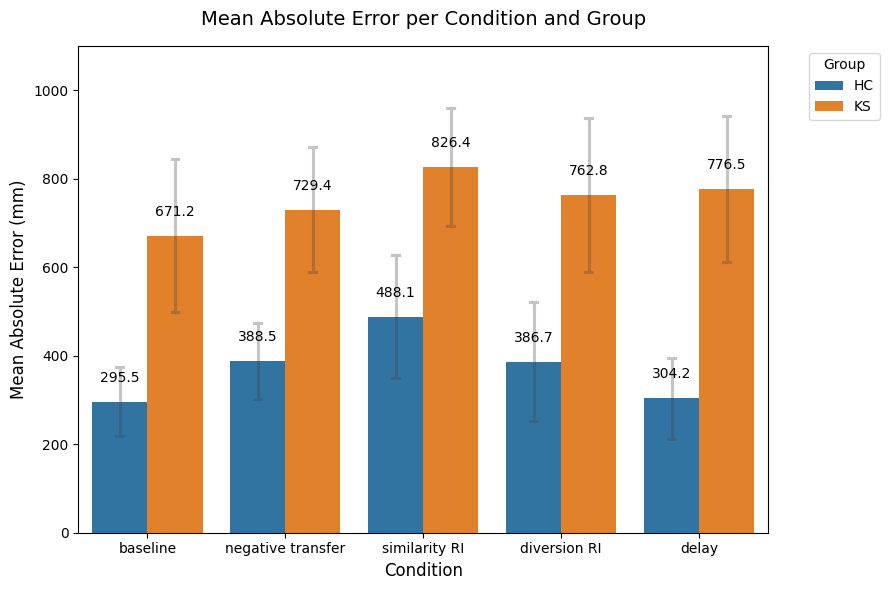

In [33]:
plt.figure(figsize=(9, 6))
ax = sns.barplot(data=plot_df, x="trial type label", y="mean_absolute_error",hue="group", errorbar="sd", capsize=0.1,linewidth=1)
for line in ax.lines: line.set_alpha(0.3)  
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f',padding=12,fontsize=10, color='black')

plt.ylabel("Mean Absolute Error (mm)", fontsize=12)
plt.xlabel("Condition", fontsize=12)
plt.title("Mean Absolute Error per Condition and Group", fontsize=14, pad=15)
plt.legend(title="Group", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 1100)
plt.tight_layout()
plt.show()

### Box plots

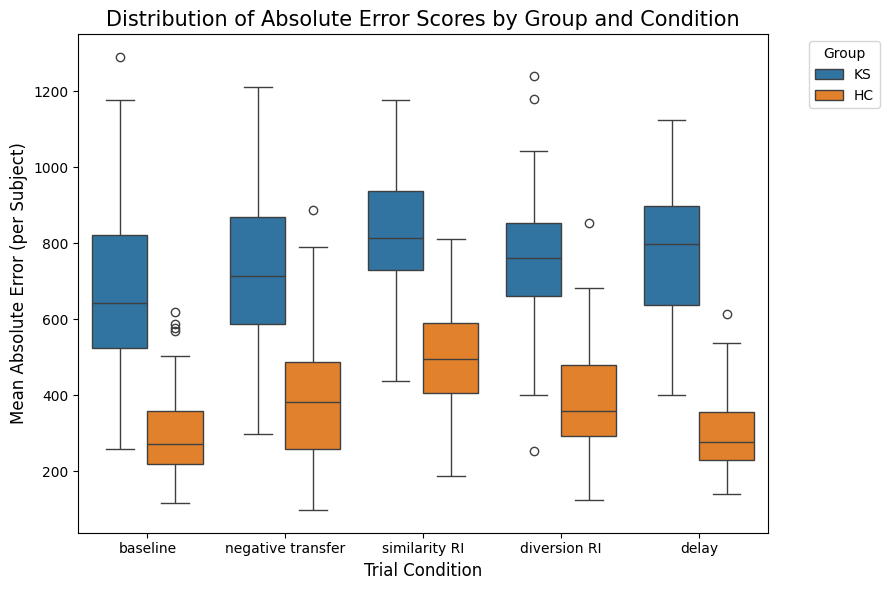

In [49]:
plt.figure(figsize=(9, 6))
ax = sns.boxplot(data=data_clean, x="trial type label", y="absolute_error_score", hue="group", hue_order=["KS", "HC"])
plt.title("Distribution of Absolute Error Scores by Group and Condition", fontsize=15)
plt.ylabel("Mean Absolute Error (per Subject)", fontsize=12)
plt.xlabel("Trial Condition", fontsize=12)
plt.legend(title="Group", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Variance analsyis - LMM

In [ ]:
# Ensure categorical variables are categorical
data_clean["ID"] = data_clean["ID"].astype("category")
data_clean["group"] = data_clean["group"].astype("category")
data_clean["trial_type"] = data_clean["trial_type"].astype("category")

In [ ]:
# --- 1. FIT THE LINEAR MIXED-EFFECTS MODEL ---
model_lme = smf.mixedlm(
    "Q('absolute_error_score') ~ C(group) * C(Q('trial_type')) + NLV_Filled + IF_Stroop_Predicted",
    data=data_clean,
    groups=data_clean["ID"] # 'ID' as the grouping variable for random intercepts
).fit()

print("--- MODEL SUMMARY ---")
print(model_lme.summary())

--- MODEL SUMMARY ---
                          Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       Q('absolute_error_score')
No. Observations:        624           Method:                   REML                     
No. Groups:              20            Scale:                    23509.9274               
Min. group size:         16            Log-Likelihood:           -4002.1831               
Max. group size:         32            Converged:                Yes                      
Mean group size:         31.2                                                             
------------------------------------------------------------------------------------------
                                            Coef.   Std.Err.   z    P>|z|  [0.025   0.975]
------------------------------------------------------------------------------------------
Intercept                                   422.279  178.356  2.368 0.018   72.709 771.850
C(gr


--- RESIDUAL NORMALITY ---
Shapiro-Wilk (Residuals): W = 0.997, p = 0.350


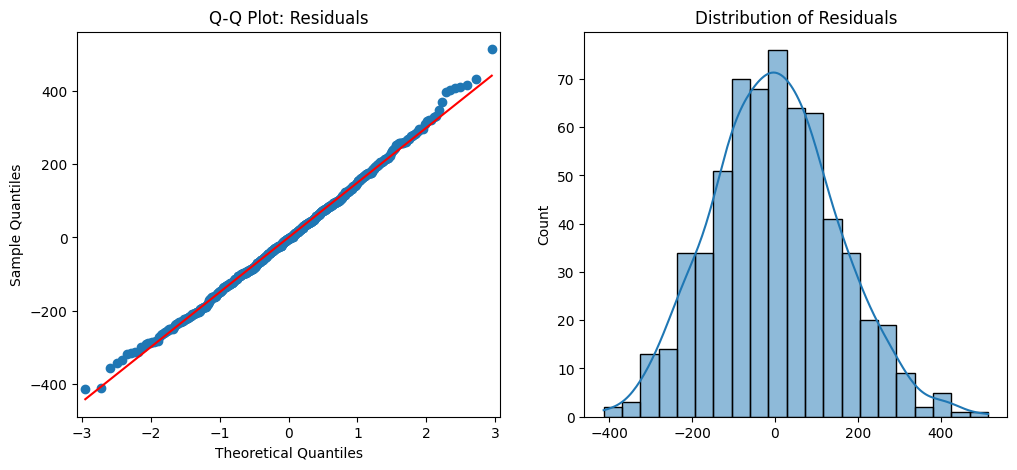


--- RANDOM EFFECTS NORMALITY ---
Shapiro-Wilk (Random Effects): W = 0.977, p = 0.889


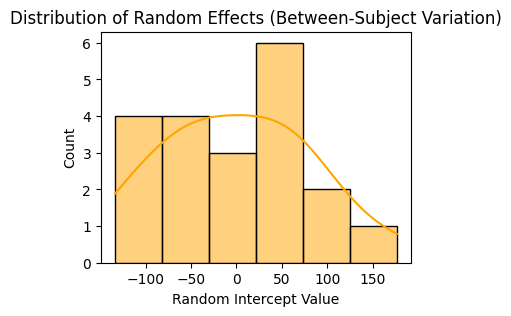


--- HOMOSCEDASTICITY (Homogeneity of Variance) ---


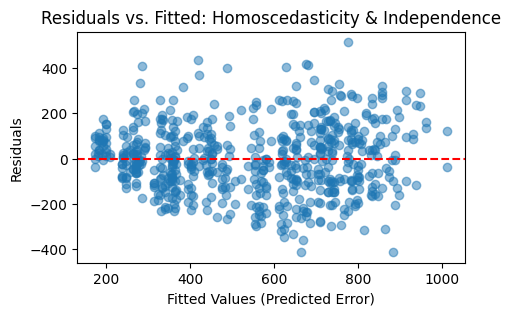


--- LINEARITY CHECK ---


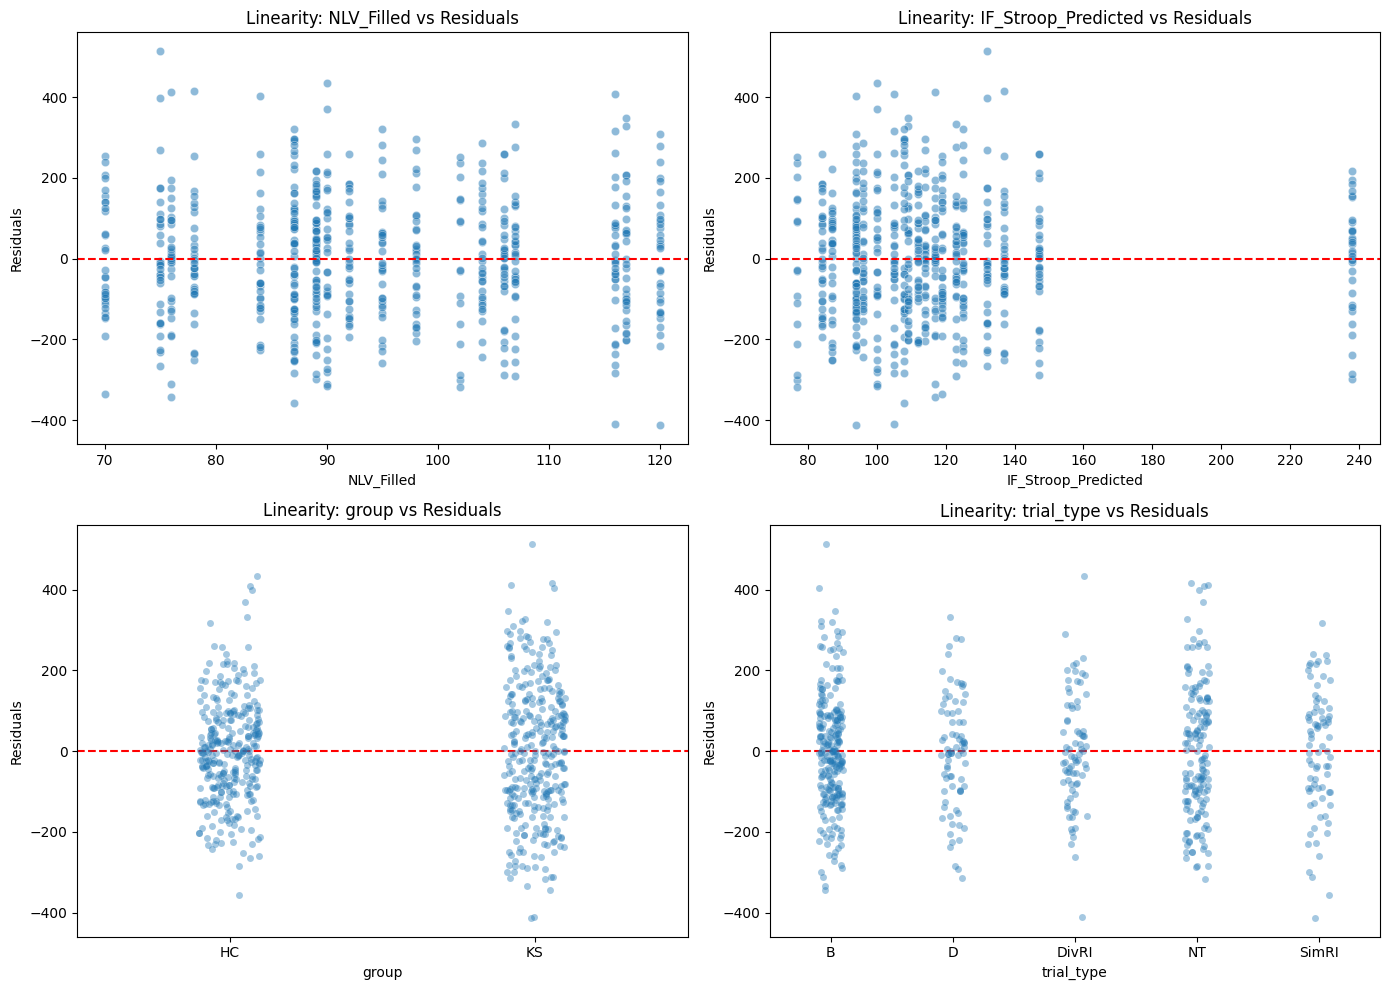

--- INDEPENDENCE OF RANDOM EFFECTS & PREDICTORS ---
Correlation between Random Intercept and NLV_Filled: r = -0.000, p = 1.000
Correlation between Random Intercept and IF_Stroop_Predicted: r = -0.000, p = 1.000


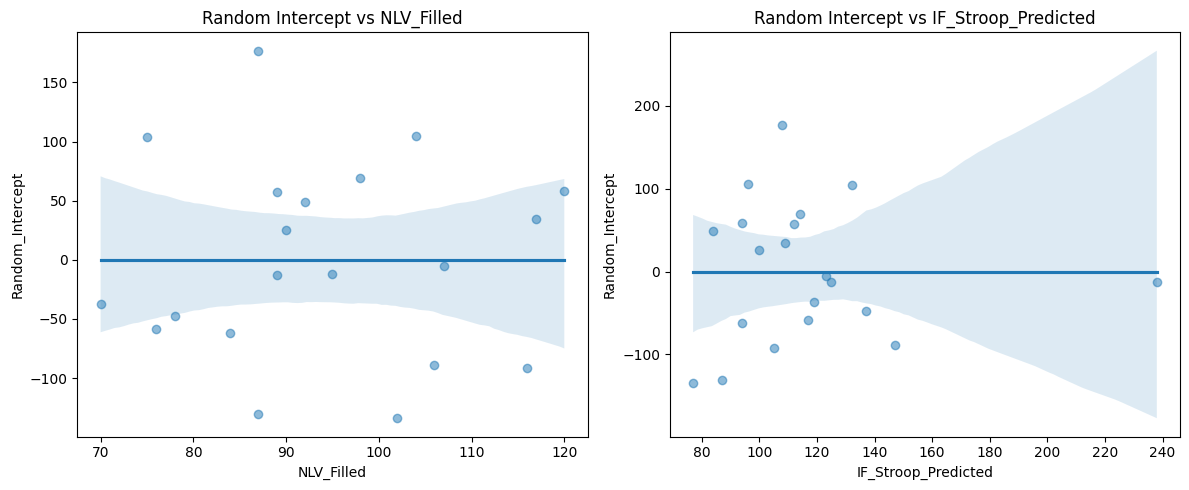

In [ ]:

# Extracting components for assumption checks
residuals = model_lme.resid
fitted_values = model_lme.fittedvalues
# Extract random intercepts (one per participant)
random_effects = [val.iloc[0] for val in model_lme.random_effects.values()]

# --- 2. ASSUMPTION: NORMALITY OF RESIDUALS ---
# the error terms (residuals) are normally distributed with a mean of zero
print("\n--- RESIDUAL NORMALITY ---")
shapiro_res = stats.shapiro(residuals)
print(f"Shapiro-Wilk (Residuals): W = {shapiro_res.statistic:.3f}, p = {shapiro_res.pvalue:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# Q-Q Plot
sm.qqplot(residuals, line='s', ax=ax[0])
ax[0].set_title("Q-Q Plot: Residuals")
# Histogram
sns.histplot(residuals, kde=True, ax=ax[1])
ax[1].set_title("Distribution of Residuals")
plt.show()

# --- 3. ASSUMPTION: NORMALITY OF RANDOM EFFECTS ---
# random effects are assumed to follow a normal distribution.
print("\n--- RANDOM EFFECTS NORMALITY ---")
shapiro_re = stats.shapiro(random_effects)
print(f"Shapiro-Wilk (Random Effects): W = {shapiro_re.statistic:.3f}, p = {shapiro_re.pvalue:.3f}")

plt.figure(figsize=(4, 3))
sns.histplot(random_effects, kde=True, color="orange")
plt.title("Distribution of Random Effects (Between-Subject Variation)")
plt.xlabel("Random Intercept Value")
plt.show()

# --- 4. ASSUMPTION: HOMOSCEDASTICITY & INDEPENDENCE ---
# variance of the residuals is constant across all levels of the predictor variables
print("\n--- HOMOSCEDASTICITY (Homogeneity of Variance) ---")
plt.figure(figsize=(5, 3))
plt.scatter(fitted_values, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted Values (Predicted Error)")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted: Homoscedasticity & Independence")
plt.show()

# --- 5. ASSUMPTION: LINEARITY ---
# relationship between the dependent variable and the independent variables (fixed and random effects) is linear.
print("\n--- LINEARITY CHECK ---")
covariates = ["NLV_Filled", "IF_Stroop_Predicted", "group", "trial_type"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, covar in enumerate(covariates):
    if data_clean[covar].dtype == 'object' or data_clean[covar].nunique() < 10:
        sns.stripplot(x=data_clean[covar], y=residuals, ax=axes[i], alpha=0.4, jitter=True)
    else:
        sns.scatterplot(x=data_clean[covar], y=residuals, ax=axes[i], alpha=0.5)
    axes[i].axhline(0, color='red', linestyle='--')
    axes[i].set_title(f"Linearity: {covar} vs Residuals", fontsize=12)
    axes[i].set_xlabel(covar)
    axes[i].set_ylabel("Residuals")

plt.tight_layout()
plt.show()
# --- 6. INDEPENDENCE OF RANDOM EFFECTS & PREDICTORS
# random effects are assumed to be independent of the fixed effect covariates.
re_dict = {id: val.iloc[0] for id, val in model_lme.random_effects.items()}
re_df = pd.DataFrame.from_dict(re_dict, orient='index', columns=['Random_Intercept'])
re_df.index.name = 'ID'
covars_per_id = data_clean.groupby('ID')[['NLV_Filled', 'IF_Stroop_Predicted']].mean()
diagnostic_df = re_df.merge(covars_per_id, on='ID')

print("--- INDEPENDENCE OF RANDOM EFFECTS & PREDICTORS ---")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, covar in enumerate(['NLV_Filled', 'IF_Stroop_Predicted']):
    sns.regplot(data=diagnostic_df, x=covar, y='Random_Intercept', ax=axes[i], scatter_kws={'alpha':0.5})
    axes[i].set_title(f"Random Intercept vs {covar}")

    # Calculate Correlation
    corr, pval = stats.pearsonr(diagnostic_df[covar], diagnostic_df['Random_Intercept'])
    print(f"Correlation between Random Intercept and {covar}: r = {corr:.3f}, p = {pval:.3f}")

plt.tight_layout()
plt.show()

## Absolute distance error - relative scores

In [11]:
data_clean = data_trials.sort_values(by=['ID', 'trial_index']).copy()
data_clean['current_baseline'] = np.where(data_clean['trial_type'] == 'B', data_clean['absolute_error_score'], np.nan) # temporary column that only has scores for baseline trials
data_clean['current_baseline'] = data_clean.groupby('ID')['current_baseline'].ffill()
data_clean['relative_error_pct'] = ((data_clean['absolute_error_score'] - data_clean['current_baseline']) / data_clean['current_baseline']) * 100 # calculate relative score
data_clean = data_clean[data_clean['trial_type'] != 'B'].dropna(subset=['relative_error_pct']).copy() # drop the baseline trials from the final modeling dataset
plot_df = (data_clean.groupby(["ID", "group", "trial_type"], as_index=False).agg(relative_error_pct=("relative_error_pct", "mean"), NLV=("NLV_Filled", "first"),IF_Stroop=("IF_Stroop_Predicted", "first")))
plot_df["trial type label"] = plot_df["trial_type"].map(condition_labels)
plot_df["trial type label"] = pd.Categorical(plot_df["trial type label"], categories=[condition_labels[c] for c in condition_order],ordered=True)

### Bar plots

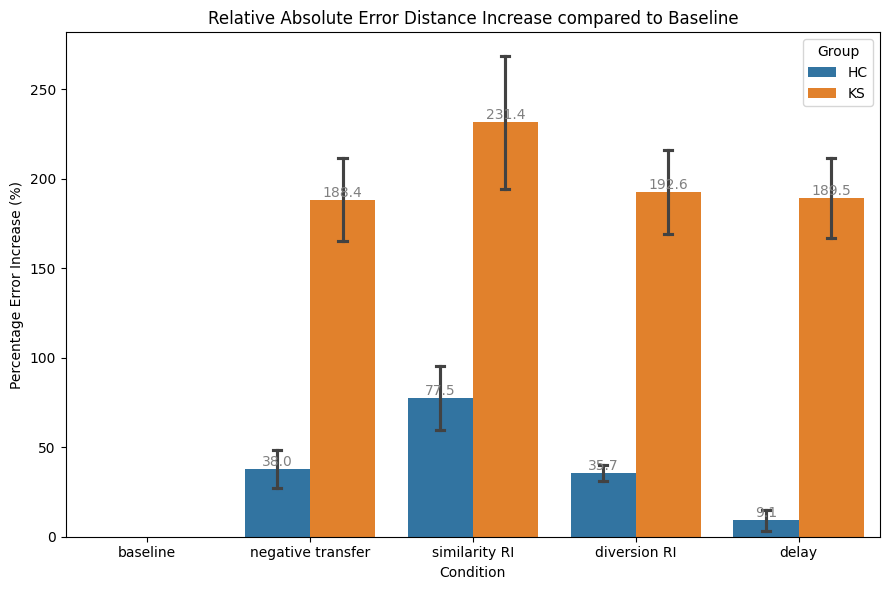

In [13]:
plt.figure(figsize=(9, 6))
ax = sns.barplot(data=plot_df, x="trial type label", y="relative_error_pct",hue="group", errorbar="se", capsize=0.1,linewidth=1)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f',padding=0,fontsize=10, color='gray')

plt.ylabel("Percentage Error Increase (%)")
plt.xlabel("Condition")
plt.title(f"Relative Absolute Error Distance Increase compared to Baseline")
plt.legend(title="Group")
plt.tight_layout()
plt.show()

### Variance analsyis - LMM

In [ ]:
# Ensure categorical variables are categorical
data_clean["ID"] = data_clean["ID"].astype("category")
data_clean["group"] = data_clean["group"].astype("category")
data_clean["trial_type"] = data_clean["trial_type"].astype("category")

In [ ]:
# --- 1. FIT THE LINEAR MIXED-EFFECTS MODEL ---
model_lme = smf.mixedlm(
    "Q('relative_error_pct') ~ C(group) * C(Q('trial_type')) + NLV_Filled + IF_Stroop_Predicted",
    data=data_clean,
    groups=data_clean["ID"] # 'ID' as the grouping variable for random intercepts
).fit()

print("--- MODEL SUMMARY ---")
print(model_lme.summary())

--- MODEL SUMMARY ---
                          Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        Q('relative_error_pct')
No. Observations:        390            Method:                    REML                   
No. Groups:              20             Scale:                     8790.1549              
Min. group size:         10             Log-Likelihood:            -2309.3118             
Max. group size:         20             Converged:                 Yes                    
Mean group size:         19.5                                                             
------------------------------------------------------------------------------------------
                                            Coef.   Std.Err.   z    P>|z|  [0.025   0.975]
------------------------------------------------------------------------------------------
Intercept                                   -99.517  109.808 -0.906 0.365 -314.738 115.703
C(gr


--- RESIDUAL NORMALITY ---
Shapiro-Wilk (Residuals): W = 0.941, p = 0.000


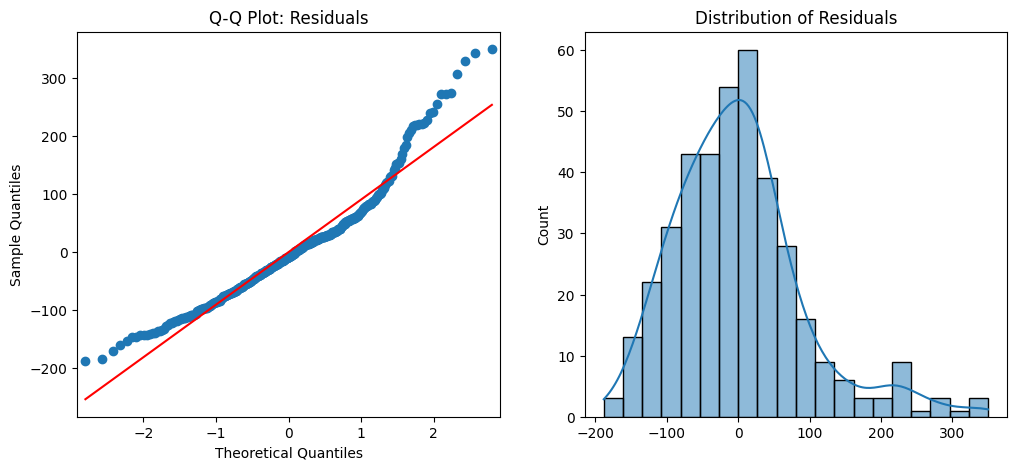


--- RANDOM EFFECTS NORMALITY ---
Shapiro-Wilk (Random Effects): W = 0.974, p = 0.827


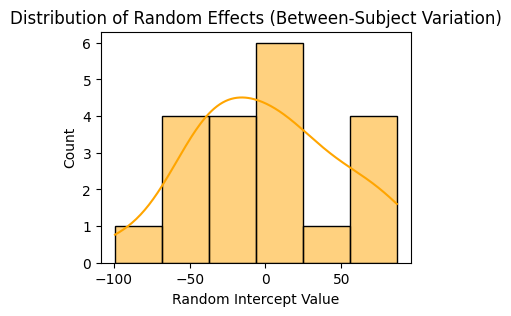


--- HOMOSCEDASTICITY (Homogeneity of Variance) ---


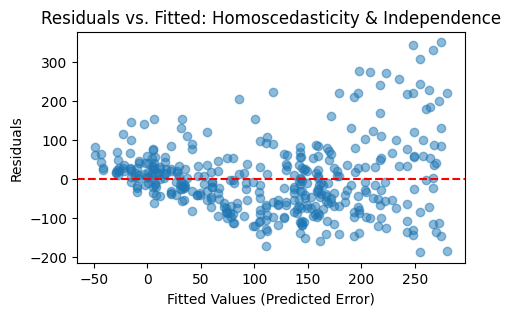


--- LINEARITY CHECK ---


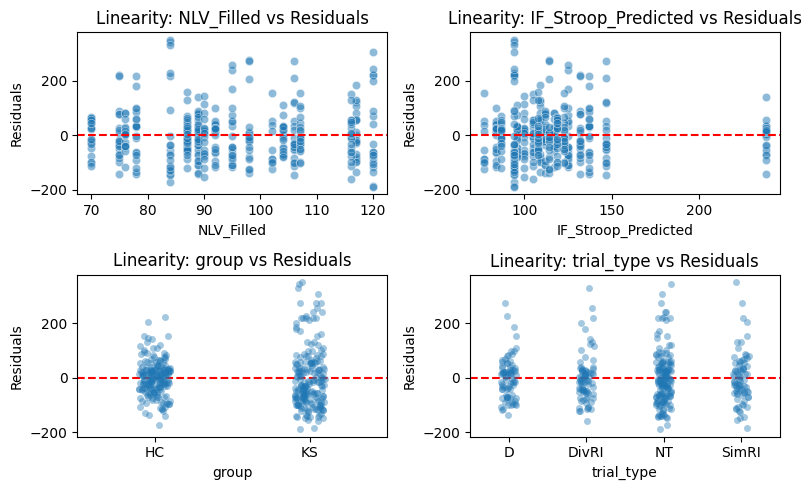

--- INDEPENDENCE OF RANDOM EFFECTS & PREDICTORS ---
Correlation between Random Intercept and NLV_Filled: r = 0.000, p = 1.000
Correlation between Random Intercept and IF_Stroop_Predicted: r = -0.000, p = 1.000


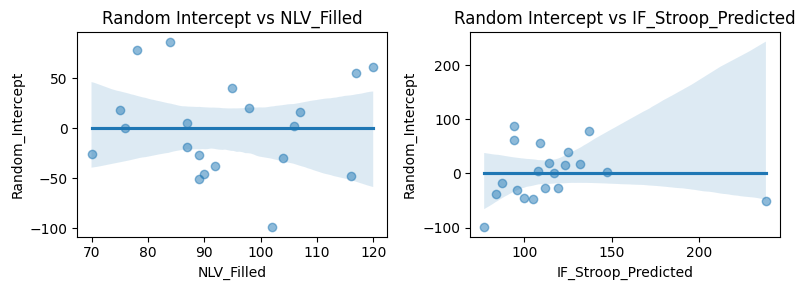

In [ ]:
# Extracting components for assumption checks
residuals = model_lme.resid
fitted_values = model_lme.fittedvalues
# Extract random intercepts (one per participant)
random_effects = [val.iloc[0] for val in model_lme.random_effects.values()]

# --- 2. ASSUMPTION: NORMALITY OF RESIDUALS ---
# the error terms (residuals) are normally distributed with a mean of zero
print("\n--- RESIDUAL NORMALITY ---")
shapiro_res = stats.shapiro(residuals)
print(f"Shapiro-Wilk (Residuals): W = {shapiro_res.statistic:.3f}, p = {shapiro_res.pvalue:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# Q-Q Plot
sm.qqplot(residuals, line='s', ax=ax[0])
ax[0].set_title("Q-Q Plot: Residuals")
# Histogram
sns.histplot(residuals, kde=True, ax=ax[1])
ax[1].set_title("Distribution of Residuals")
plt.show()

# --- 3. ASSUMPTION: NORMALITY OF RANDOM EFFECTS ---
# random effects are assumed to follow a normal distribution.
print("\n--- RANDOM EFFECTS NORMALITY ---")
shapiro_re = stats.shapiro(random_effects)
print(f"Shapiro-Wilk (Random Effects): W = {shapiro_re.statistic:.3f}, p = {shapiro_re.pvalue:.3f}")

plt.figure(figsize=(4, 3))
sns.histplot(random_effects, kde=True, color="orange")
plt.title("Distribution of Random Effects (Between-Subject Variation)")
plt.xlabel("Random Intercept Value")
plt.show()

# --- 4. ASSUMPTION: HOMOSCEDASTICITY & INDEPENDENCE ---
# variance of the residuals is constant across all levels of the predictor variables
print("\n--- HOMOSCEDASTICITY (Homogeneity of Variance) ---")
plt.figure(figsize=(5, 3))
plt.scatter(fitted_values, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted Values (Predicted Error)")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted: Homoscedasticity & Independence")
plt.show()

# --- 5. ASSUMPTION: LINEARITY ---
# relationship between the dependent variable and the independent variables (fixed and random effects) is linear.
print("\n--- LINEARITY CHECK ---")
covariates = ["NLV_Filled", "IF_Stroop_Predicted", "group", "trial_type"]

fig, axes = plt.subplots(2, 2, figsize=(8, 5))
axes = axes.flatten()

for i, covar in enumerate(covariates):
    if data_clean[covar].dtype == 'object' or data_clean[covar].nunique() < 10:
        sns.stripplot(x=data_clean[covar], y=residuals, ax=axes[i], alpha=0.4, jitter=True)
    else:
        sns.scatterplot(x=data_clean[covar], y=residuals, ax=axes[i], alpha=0.5)
    axes[i].axhline(0, color='red', linestyle='--')
    axes[i].set_title(f"Linearity: {covar} vs Residuals", fontsize=12)
    axes[i].set_xlabel(covar)
    axes[i].set_ylabel("Residuals")

plt.tight_layout()
plt.show()
# --- 6. INDEPENDENCE OF RANDOM EFFECTS & PREDICTORS
# random effects are assumed to be independent of the fixed effect covariates.
re_dict = {id: val.iloc[0] for id, val in model_lme.random_effects.items()}
re_df = pd.DataFrame.from_dict(re_dict, orient='index', columns=['Random_Intercept'])
re_df.index.name = 'ID'
covars_per_id = data_clean.groupby('ID')[['NLV_Filled', 'IF_Stroop_Predicted']].mean()
diagnostic_df = re_df.merge(covars_per_id, on='ID')

print("--- INDEPENDENCE OF RANDOM EFFECTS & PREDICTORS ---")
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

for i, covar in enumerate(['NLV_Filled', 'IF_Stroop_Predicted']):
    sns.regplot(data=diagnostic_df, x=covar, y='Random_Intercept', ax=axes[i], scatter_kws={'alpha':0.5})
    axes[i].set_title(f"Random Intercept vs {covar}")

    # Calculate Correlation
    corr, pval = stats.pearsonr(diagnostic_df[covar], diagnostic_df['Random_Intercept'])
    print(f"Correlation between Random Intercept and {covar}: r = {corr:.3f}, p = {pval:.3f}")

plt.tight_layout()
plt.show()

## Best-fit scores

In [20]:
data_clean = data_trials.dropna(subset=["bestfit_score"])
plot_df = (data_clean.groupby(["ID", "group", "trial_type"], as_index=False).agg(mean_bestfit=("bestfit_score", "mean"), NLV=("NLV_Filled", "first"),IF_Stroop=("IF_Stroop_Predicted", "first")))

plot_df["trial type label"] = plot_df["trial_type"].map(condition_labels)
plot_df["trial type label"] = pd.Categorical(plot_df["trial type label"],categories=[condition_labels[c] for c in condition_order],ordered=True)

In [50]:
data_clean["trial type label"] = data_clean["trial_type"].map(condition_labels)
desc_table = (data_clean.groupby(["group", "trial type label"])["bestfit_score"].describe())
desc_table['std_err'] = desc_table['std'] / np.sqrt(desc_table['count'])

display(desc_table)

count        mean         std         min  \
group trial type label                                               
HC    baseline           114.0  223.043858   48.564948   89.661760   
      delay               38.0  244.803081   55.907802  139.299944   
      diversion RI        38.0  266.616790   65.208932  125.280713   
      negative transfer   76.0  249.826296   64.153977   97.655077   
      similarity RI       38.0  248.516416   41.375349  182.796903   
KS    baseline           120.0  360.358137  127.472497  199.633972   
      delay               40.0  393.437366  127.895776  229.080341   
      diversion RI        40.0  383.167508  156.225604  189.628057   
      negative transfer   80.0  385.744702  121.712364  207.009840   
      similarity RI       40.0  364.429236  143.300690  189.658613   

                                25%         50%         75%         max  \
group trial type label                                                    
HC    baseline           193.492562  223.411943  254.340546  338.744152   
      delay              200.985731  247.098701  276.654872  350.819672   
      diversion RI       225.034920  258.727858  309.622916  406.751719   
      negative transfer  210.648856  246.131372  278.252105  403.886089   
      similarity RI      220.262693  238.402980  265.788999  398.017814   
KS    baseline           282.406070  324.699710  389.964622  956.395364   
      delay              314.506055  350.303768  437.432517  874.497932   
      diversion RI       314.298560  344.258347  394.474098  982.969158   
      negative transfer  297.653484  366.669470  419.122636  879.808098   
      similarity RI      282.537010  311.081491  404.838184  873.687137   

                           std_err  
group trial type label              
HC    baseline            4.548524  
      delay               9.069443  
      diversion RI       10.578286  
      negative transfer   7.358966  
      similarity RI       6.711968  
KS    baseline           11.636594  
      delay              20.222098  
      diversion RI       24.701437  
      negative transfer  13.607856  
      similarity RI      22.657829

### Bar plots

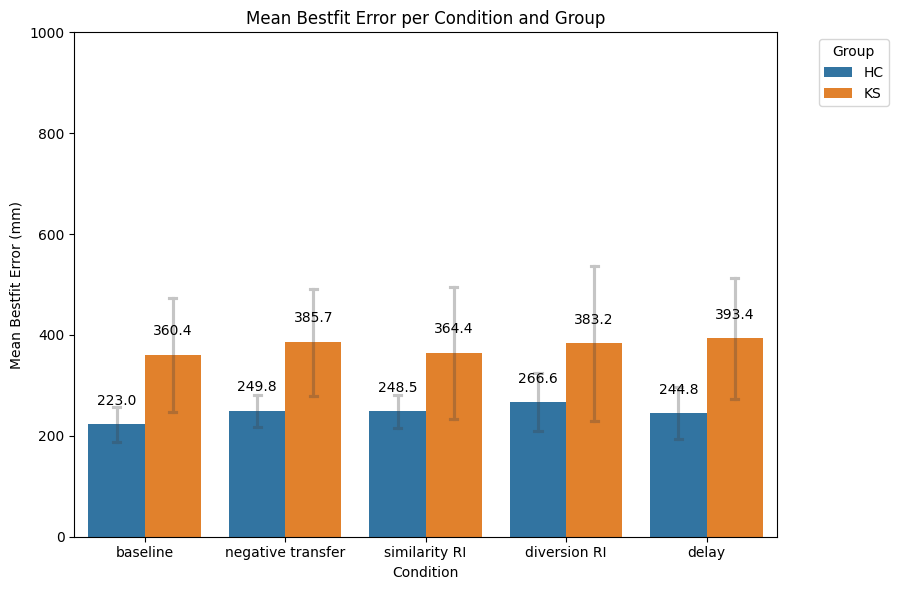

In [22]:
plt.figure(figsize=(9, 6))
ax = sns.barplot(data=plot_df, x="trial type label", y="mean_bestfit",hue="group", errorbar="sd", capsize=0.1,linewidth=1)
for line in ax.lines: line.set_alpha(0.3)  
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f',padding=12,fontsize=10, color='black')

plt.ylabel("Mean Bestfit Error (mm)")
plt.xlabel("Condition")
plt.title("Mean Bestfit Error per Condition and Group")
plt.legend(title="Group", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.ylim(0, 1000)
plt.show()


### Box plots

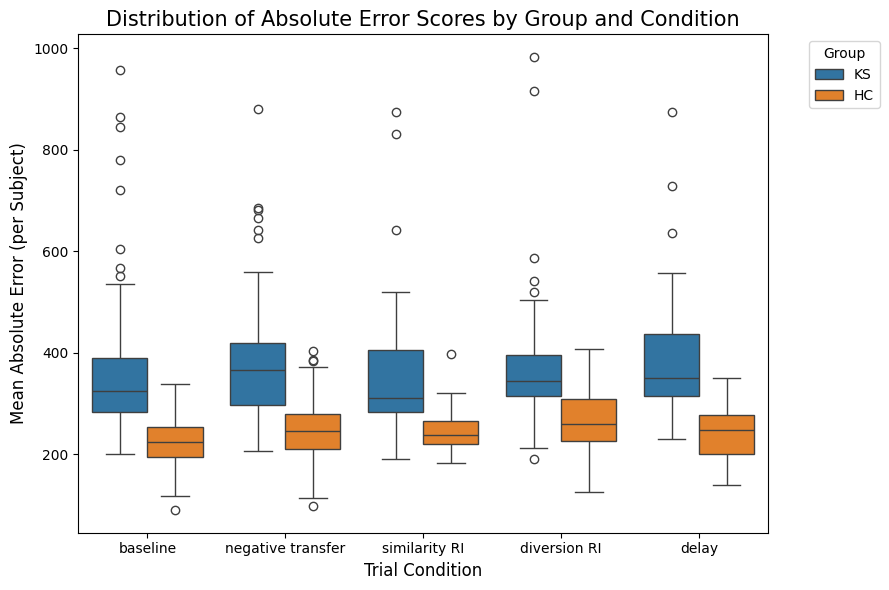

In [51]:
plt.figure(figsize=(9, 6))
ax = sns.boxplot(data=data_clean, x="trial type label", y="bestfit_score", hue="group", hue_order=["KS", "HC"])
plt.title("Distribution of Absolute Error Scores by Group and Condition", fontsize=15)
plt.ylabel("Mean Absolute Error (per Subject)", fontsize=12)
plt.xlabel("Trial Condition", fontsize=12)
plt.legend(title="Group", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Variance analsyis - LMM

In [ ]:
# Ensure categorical variables are categorical
data_clean["ID"] = data_clean["ID"].astype("category")
data_clean["group"] = data_clean["group"].astype("category")
data_clean["trial_type"] = data_clean["trial_type"].astype("category")

In [ ]:
# --- 1. FIT THE LINEAR MIXED-EFFECTS MODEL ---
model_lme = smf.mixedlm(
    "Q('bestfit_score') ~ C(group) * C(Q('trial_type')) + NLV_Filled + IF_Stroop_Predicted",
    data=data_clean,
    groups=data_clean["ID"] # 'ID' as the grouping variable for random intercepts
).fit()

print("--- MODEL SUMMARY ---")
print(model_lme.summary())

--- MODEL SUMMARY ---
                          Mixed Linear Model Regression Results
Model:                     MixedLM         Dependent Variable:         Q('bestfit_score')
No. Observations:          624             Method:                     REML              
No. Groups:                20              Scale:                      6893.1251         
Min. group size:           16              Log-Likelihood:             -3630.7318        
Max. group size:           32              Converged:                  Yes               
Mean group size:           31.2                                                          
-----------------------------------------------------------------------------------------
                                            Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
-----------------------------------------------------------------------------------------
Intercept                                   287.398  122.007  2.356 0.018  48.268 526.527
C(group)[T.KS]


--- RESIDUAL NORMALITY ---
Shapiro-Wilk (Residuals): W = 0.953, p = 0.000


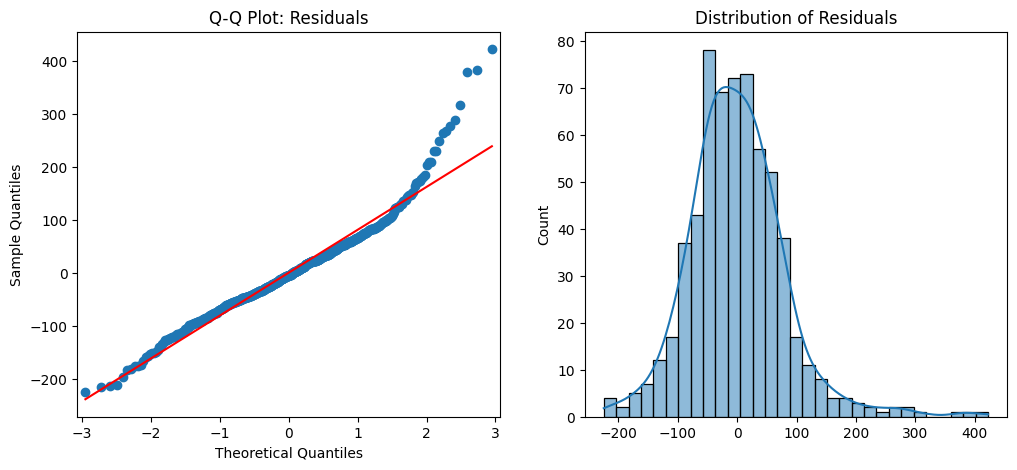


--- RANDOM EFFECTS NORMALITY ---
Shapiro-Wilk (Random Effects): W = 0.722, p = 0.000


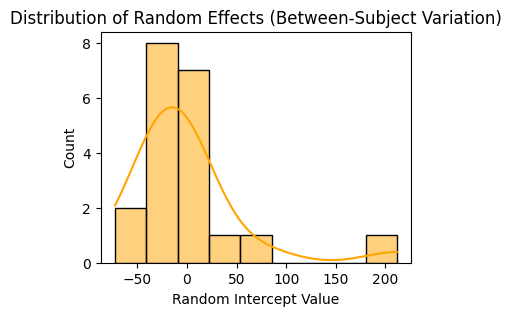


--- HOMOSCEDASTICITY (Homogeneity of Variance) ---


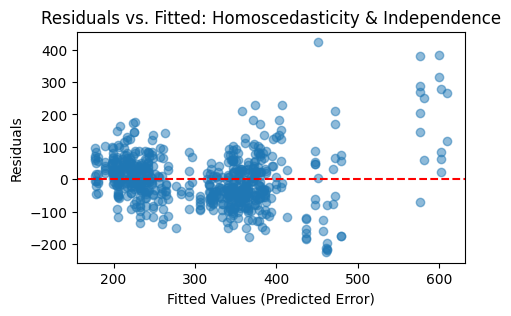


--- LINEARITY CHECK ---


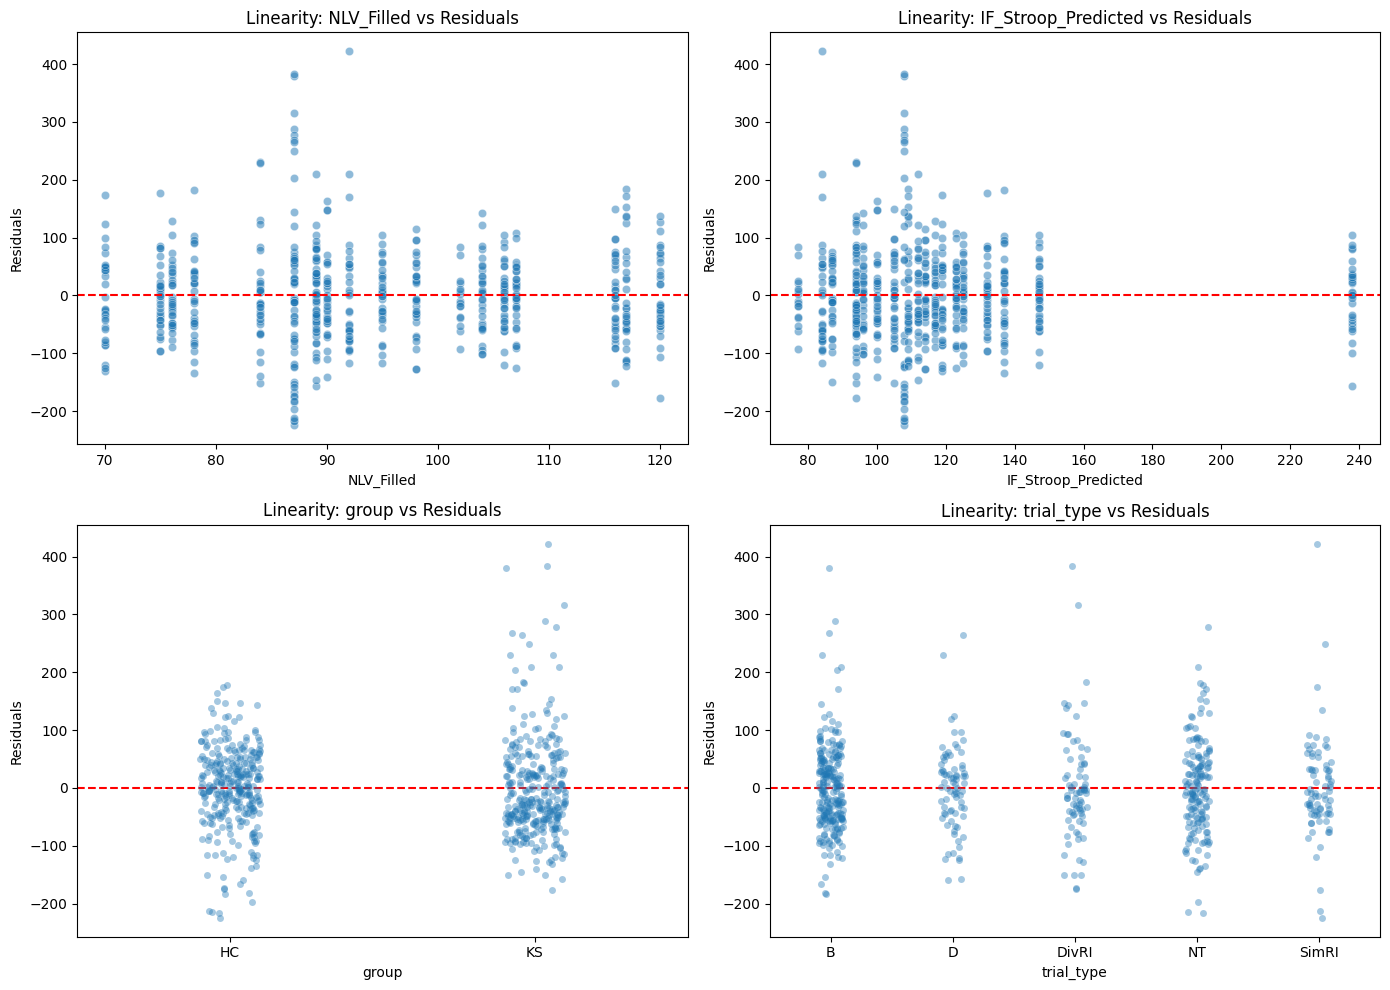

--- INDEPENDENCE OF RANDOM EFFECTS & PREDICTORS ---
Correlation between Random Intercept and NLV_Filled: r = 0.000, p = 1.000
Correlation between Random Intercept and IF_Stroop_Predicted: r = 0.000, p = 1.000


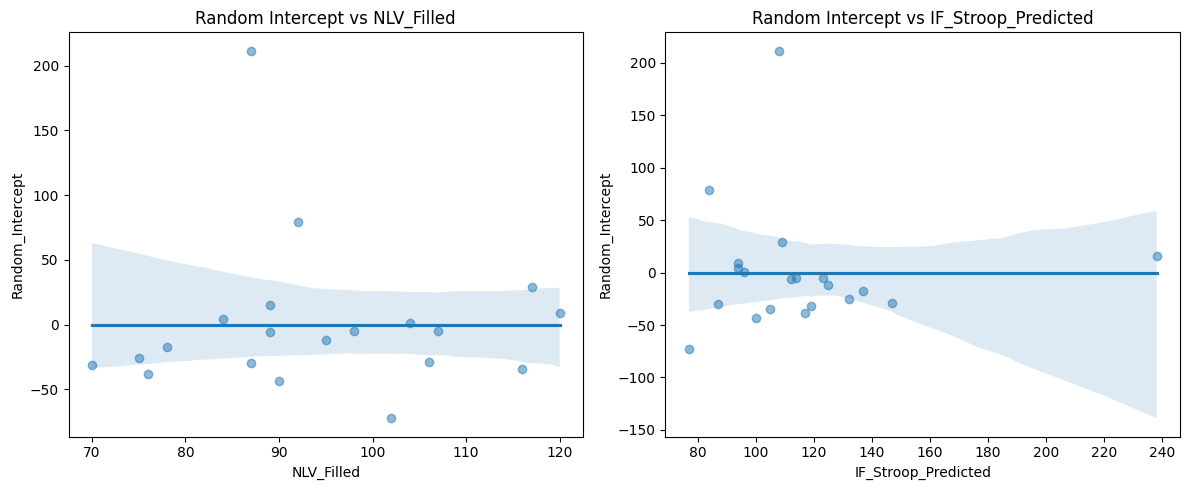

In [ ]:

# Extracting components for assumption checks
residuals = model_lme.resid
fitted_values = model_lme.fittedvalues
# Extract random intercepts (one per participant)
random_effects = [val.iloc[0] for val in model_lme.random_effects.values()]

# --- 2. ASSUMPTION: NORMALITY OF RESIDUALS ---
# the error terms (residuals) are normally distributed with a mean of zero
print("\n--- RESIDUAL NORMALITY ---")
shapiro_res = stats.shapiro(residuals)
print(f"Shapiro-Wilk (Residuals): W = {shapiro_res.statistic:.3f}, p = {shapiro_res.pvalue:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# Q-Q Plot
sm.qqplot(residuals, line='s', ax=ax[0])
ax[0].set_title("Q-Q Plot: Residuals")
# Histogram
sns.histplot(residuals, kde=True, ax=ax[1])
ax[1].set_title("Distribution of Residuals")
plt.show()

# --- 3. ASSUMPTION: NORMALITY OF RANDOM EFFECTS ---
# random effects are assumed to follow a normal distribution.
print("\n--- RANDOM EFFECTS NORMALITY ---")
shapiro_re = stats.shapiro(random_effects)
print(f"Shapiro-Wilk (Random Effects): W = {shapiro_re.statistic:.3f}, p = {shapiro_re.pvalue:.3f}")

plt.figure(figsize=(4, 3))
sns.histplot(random_effects, kde=True, color="orange")
plt.title("Distribution of Random Effects (Between-Subject Variation)")
plt.xlabel("Random Intercept Value")
plt.show()

# --- 4. ASSUMPTION: HOMOSCEDASTICITY & INDEPENDENCE ---
# variance of the residuals is constant across all levels of the predictor variables
print("\n--- HOMOSCEDASTICITY (Homogeneity of Variance) ---")
plt.figure(figsize=(5, 3))
plt.scatter(fitted_values, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted Values (Predicted Error)")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted: Homoscedasticity & Independence")
plt.show()

# --- 5. ASSUMPTION: LINEARITY ---
# relationship between the dependent variable and the independent variables (fixed and random effects) is linear.
print("\n--- LINEARITY CHECK ---")
covariates = ["NLV_Filled", "IF_Stroop_Predicted", "group", "trial_type"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, covar in enumerate(covariates):
    if data_clean[covar].dtype == 'object' or data_clean[covar].nunique() < 10:
        sns.stripplot(x=data_clean[covar], y=residuals, ax=axes[i], alpha=0.4, jitter=True)
    else:
        sns.scatterplot(x=data_clean[covar], y=residuals, ax=axes[i], alpha=0.5)
    axes[i].axhline(0, color='red', linestyle='--')
    axes[i].set_title(f"Linearity: {covar} vs Residuals", fontsize=12)
    axes[i].set_xlabel(covar)
    axes[i].set_ylabel("Residuals")

plt.tight_layout()
plt.show()
# --- 6. INDEPENDENCE OF RANDOM EFFECTS & PREDICTORS
# random effects are assumed to be independent of the fixed effect covariates.
re_dict = {id: val.iloc[0] for id, val in model_lme.random_effects.items()}
re_df = pd.DataFrame.from_dict(re_dict, orient='index', columns=['Random_Intercept'])
re_df.index.name = 'ID'
covars_per_id = data_clean.groupby('ID')[['NLV_Filled', 'IF_Stroop_Predicted']].mean()
diagnostic_df = re_df.merge(covars_per_id, on='ID')

print("--- INDEPENDENCE OF RANDOM EFFECTS & PREDICTORS ---")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, covar in enumerate(['NLV_Filled', 'IF_Stroop_Predicted']):
    sns.regplot(data=diagnostic_df, x=covar, y='Random_Intercept', ax=axes[i], scatter_kws={'alpha':0.5})
    axes[i].set_title(f"Random Intercept vs {covar}")

    # Calculate Correlation
    corr, pval = stats.pearsonr(diagnostic_df[covar], diagnostic_df['Random_Intercept'])
    print(f"Correlation between Random Intercept and {covar}: r = {corr:.3f}, p = {pval:.3f}")

plt.tight_layout()
plt.show()

## Best-fit scores - relative scores

In [ ]:
data_clean = data_trials.sort_values(by=['ID', 'trial_index']).copy()
data_clean['current_baseline'] = np.where(data_clean['trial_type'] == 'B', data_clean['bestfit_score'], np.nan) # temporary column that only has scores for baseline trials
data_clean['current_baseline'] = data_clean.groupby('ID')['current_baseline'].ffill()
data_clean['relative_error_pct'] = ((data_clean['bestfit_score'] - data_clean['current_baseline']) / data_clean['current_baseline']) * 100 # calculate relative score
data_clean = data_clean[data_clean['trial_type'] != 'B'].dropna(subset=['relative_error_pct']).copy() # drop the baseline trials from the final modeling dataset
plot_df = (data_clean.groupby(["ID", "group", "trial_type"], as_index=False).agg(relative_error_pct=("relative_error_pct", "mean"), NLV=("NLV_Filled", "first"),IF_Stroop=("IF_Stroop_Predicted", "first")))
plot_df["trial type label"] = plot_df["trial_type"].map(condition_labels)
plot_df["trial type label"] = pd.Categorical(plot_df["trial type label"], categories=[condition_labels[c] for c in condition_order],ordered=True)

### Bar plots

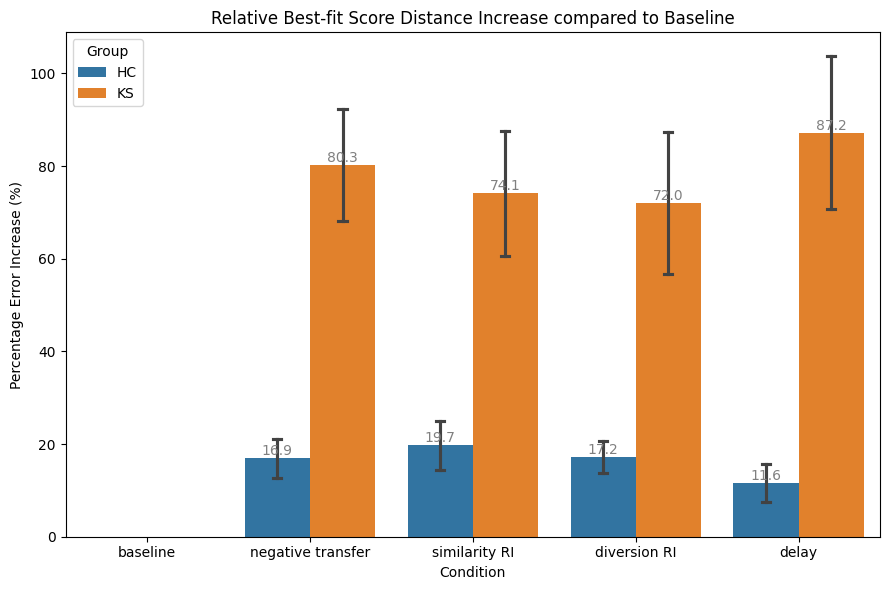

In [ ]:
plt.figure(figsize=(9, 6))
ax = sns.barplot(data=plot_df, x="trial type label", y="relative_error_pct",hue="group", errorbar="se", capsize=0.1,linewidth=1)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f',padding=0,fontsize=10, color='gray')

plt.ylabel("Percentage Error Increase (%)")
plt.xlabel("Condition")
plt.title(f"Relative Best-fit Score Distance Increase compared to Baseline")
plt.legend(title="Group")
plt.tight_layout()
plt.show()

### Variance analsyis - LMM

In [ ]:
# Ensure categorical variables are categorical
data_clean["ID"] = data_clean["ID"].astype("category")
data_clean["group"] = data_clean["group"].astype("category")
data_clean["trial_type"] = data_clean["trial_type"].astype("category")

In [ ]:
# --- 1. FIT THE LINEAR MIXED-EFFECTS MODEL ---
model_lme = smf.mixedlm(
    "Q('relative_error_pct') ~ C(group) * C(Q('trial_type')) + NLV_Filled + IF_Stroop_Predicted",
    data=data_clean,
    groups=data_clean["ID"] # 'ID' as the grouping variable for random intercepts
).fit()

print("--- MODEL SUMMARY ---")
print(model_lme.summary())

--- MODEL SUMMARY ---
                          Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        Q('relative_error_pct')
No. Observations:        390            Method:                    REML                   
No. Groups:              20             Scale:                     2449.6151              
Min. group size:         10             Log-Likelihood:            -2068.4498             
Max. group size:         20             Converged:                 Yes                    
Mean group size:         19.5                                                             
------------------------------------------------------------------------------------------
                                            Coef.   Std.Err.   z    P>|z|  [0.025   0.975]
------------------------------------------------------------------------------------------
Intercept                                    -5.141   64.749 -0.079 0.937 -132.046 121.764
C(gr


--- RESIDUAL NORMALITY ---
Shapiro-Wilk (Residuals): W = 0.933, p = 0.000


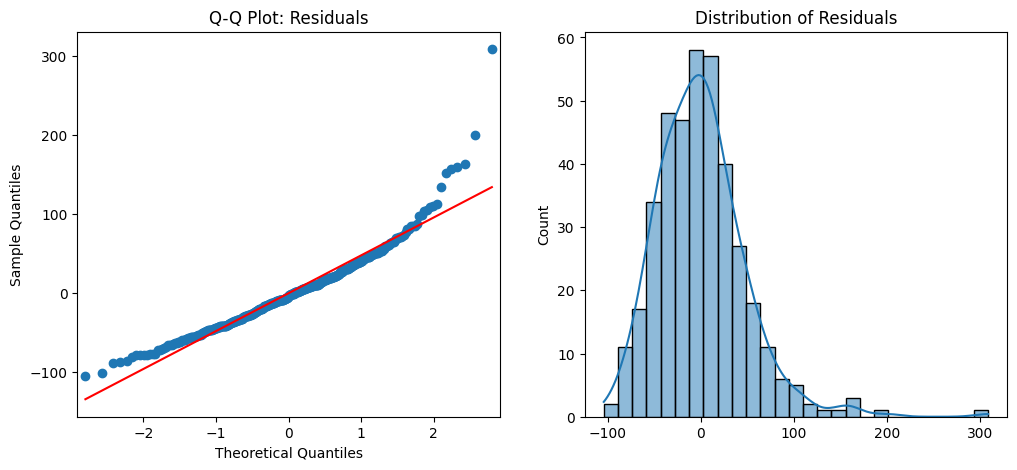


--- RANDOM EFFECTS NORMALITY ---
Shapiro-Wilk (Random Effects): W = 0.951, p = 0.386


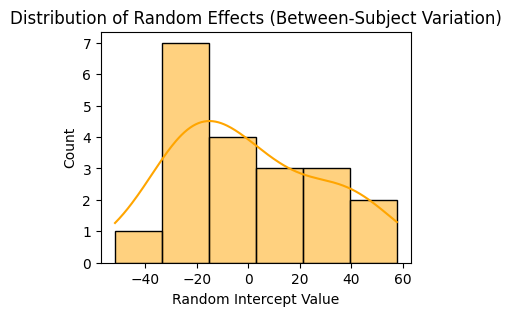


--- HOMOSCEDASTICITY (Homogeneity of Variance) ---


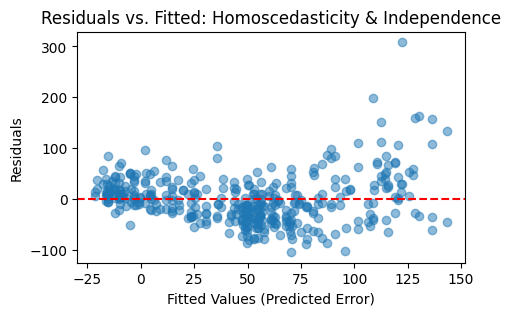


--- LINEARITY CHECK ---


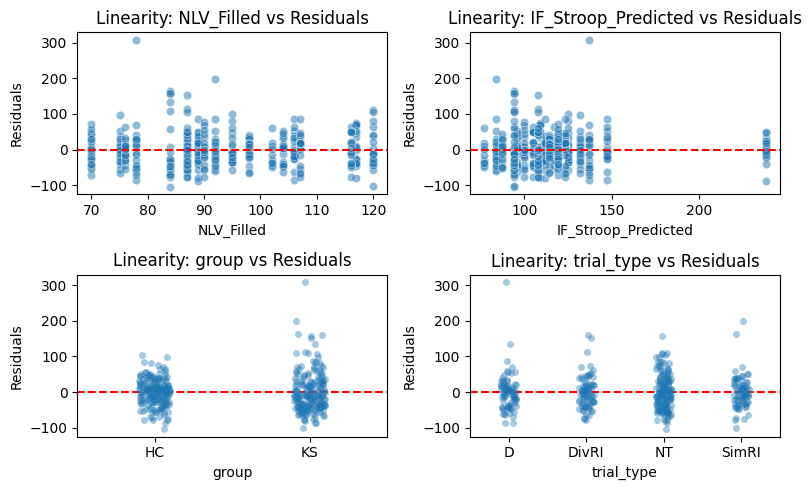

--- INDEPENDENCE OF RANDOM EFFECTS & PREDICTORS ---
Correlation between Random Intercept and NLV_Filled: r = -0.000, p = 1.000
Correlation between Random Intercept and IF_Stroop_Predicted: r = -0.000, p = 1.000


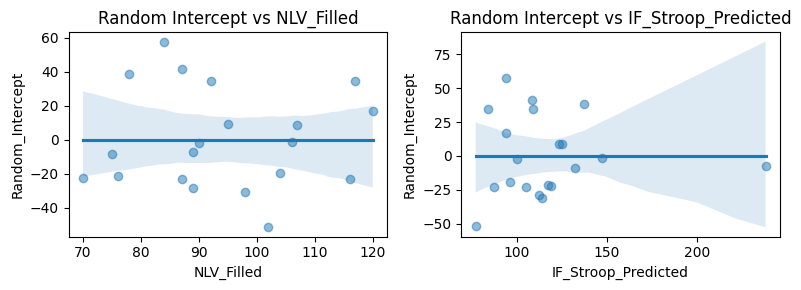

In [ ]:
# Extracting components for assumption checks
residuals = model_lme.resid
fitted_values = model_lme.fittedvalues
# Extract random intercepts (one per participant)
random_effects = [val.iloc[0] for val in model_lme.random_effects.values()]

# --- 2. ASSUMPTION: NORMALITY OF RESIDUALS ---
# the error terms (residuals) are normally distributed with a mean of zero
print("\n--- RESIDUAL NORMALITY ---")
shapiro_res = stats.shapiro(residuals)
print(f"Shapiro-Wilk (Residuals): W = {shapiro_res.statistic:.3f}, p = {shapiro_res.pvalue:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# Q-Q Plot
sm.qqplot(residuals, line='s', ax=ax[0])
ax[0].set_title("Q-Q Plot: Residuals")
# Histogram
sns.histplot(residuals, kde=True, ax=ax[1])
ax[1].set_title("Distribution of Residuals")
plt.show()

# --- 3. ASSUMPTION: NORMALITY OF RANDOM EFFECTS ---
# random effects are assumed to follow a normal distribution.
print("\n--- RANDOM EFFECTS NORMALITY ---")
shapiro_re = stats.shapiro(random_effects)
print(f"Shapiro-Wilk (Random Effects): W = {shapiro_re.statistic:.3f}, p = {shapiro_re.pvalue:.3f}")

plt.figure(figsize=(4, 3))
sns.histplot(random_effects, kde=True, color="orange")
plt.title("Distribution of Random Effects (Between-Subject Variation)")
plt.xlabel("Random Intercept Value")
plt.show()

# --- 4. ASSUMPTION: HOMOSCEDASTICITY & INDEPENDENCE ---
# variance of the residuals is constant across all levels of the predictor variables
print("\n--- HOMOSCEDASTICITY (Homogeneity of Variance) ---")
plt.figure(figsize=(5, 3))
plt.scatter(fitted_values, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted Values (Predicted Error)")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted: Homoscedasticity & Independence")
plt.show()

# --- 5. ASSUMPTION: LINEARITY ---
# relationship between the dependent variable and the independent variables (fixed and random effects) is linear.
print("\n--- LINEARITY CHECK ---")
covariates = ["NLV_Filled", "IF_Stroop_Predicted", "group", "trial_type"]

fig, axes = plt.subplots(2, 2, figsize=(8, 5))
axes = axes.flatten()

for i, covar in enumerate(covariates):
    if data_clean[covar].dtype == 'object' or data_clean[covar].nunique() < 10:
        sns.stripplot(x=data_clean[covar], y=residuals, ax=axes[i], alpha=0.4, jitter=True)
    else:
        sns.scatterplot(x=data_clean[covar], y=residuals, ax=axes[i], alpha=0.5)
    axes[i].axhline(0, color='red', linestyle='--')
    axes[i].set_title(f"Linearity: {covar} vs Residuals", fontsize=12)
    axes[i].set_xlabel(covar)
    axes[i].set_ylabel("Residuals")

plt.tight_layout()
plt.show()
# --- 6. INDEPENDENCE OF RANDOM EFFECTS & PREDICTORS
# random effects are assumed to be independent of the fixed effect covariates.
re_dict = {id: val.iloc[0] for id, val in model_lme.random_effects.items()}
re_df = pd.DataFrame.from_dict(re_dict, orient='index', columns=['Random_Intercept'])
re_df.index.name = 'ID'
covars_per_id = data_clean.groupby('ID')[['NLV_Filled', 'IF_Stroop_Predicted']].mean()
diagnostic_df = re_df.merge(covars_per_id, on='ID')

print("--- INDEPENDENCE OF RANDOM EFFECTS & PREDICTORS ---")
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

for i, covar in enumerate(['NLV_Filled', 'IF_Stroop_Predicted']):
    sns.regplot(data=diagnostic_df, x=covar, y='Random_Intercept', ax=axes[i], scatter_kws={'alpha':0.5})
    axes[i].set_title(f"Random Intercept vs {covar}")

    # Calculate Correlation
    corr, pval = stats.pearsonr(diagnostic_df[covar], diagnostic_df['Random_Intercept'])
    print(f"Correlation between Random Intercept and {covar}: r = {corr:.3f}, p = {pval:.3f}")

plt.tight_layout()
plt.show()

## Conjuctional errors

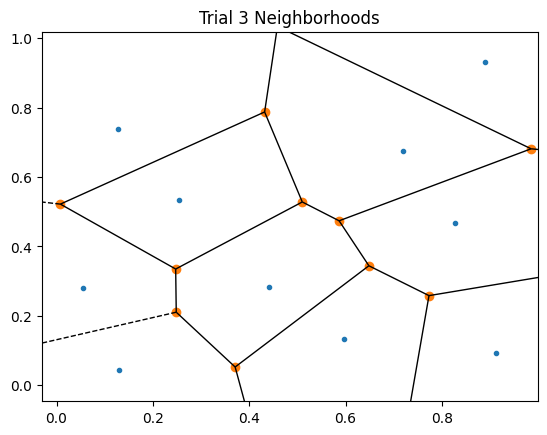

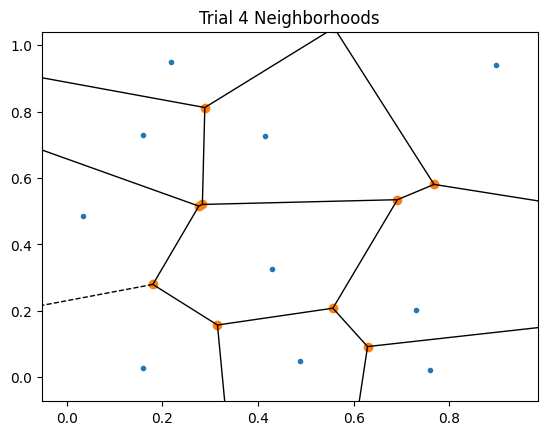

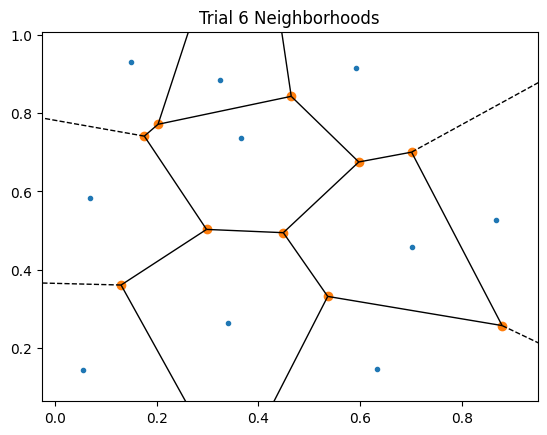

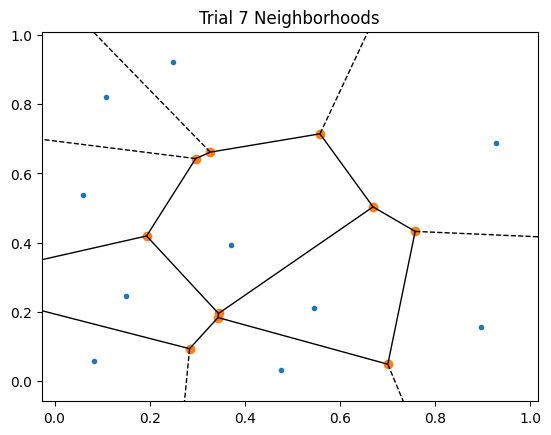

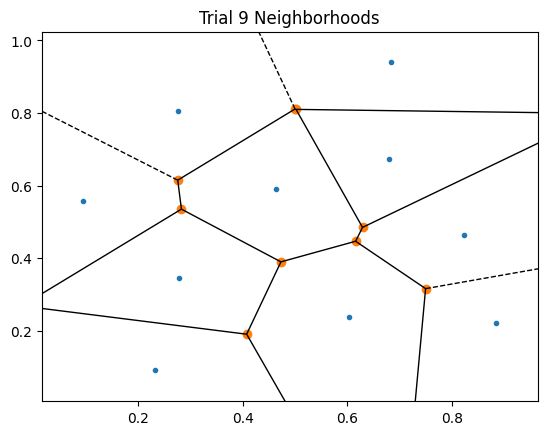

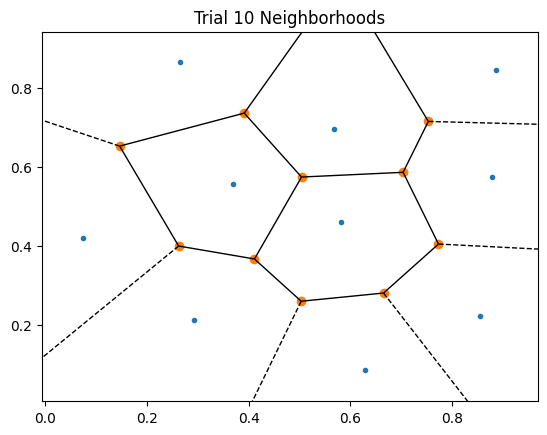

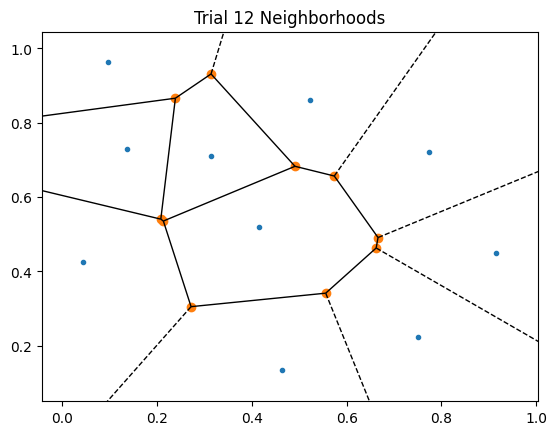

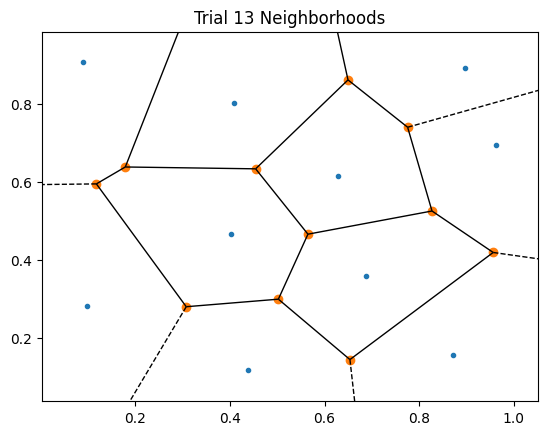

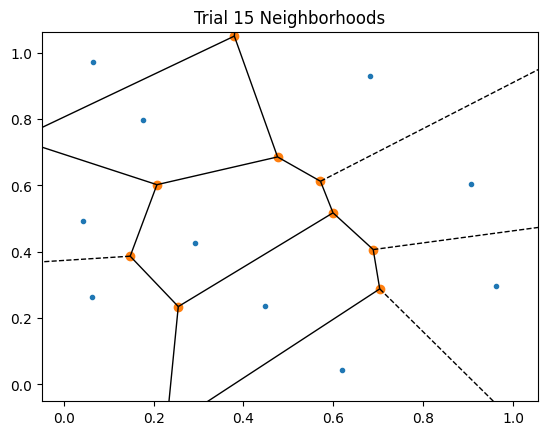

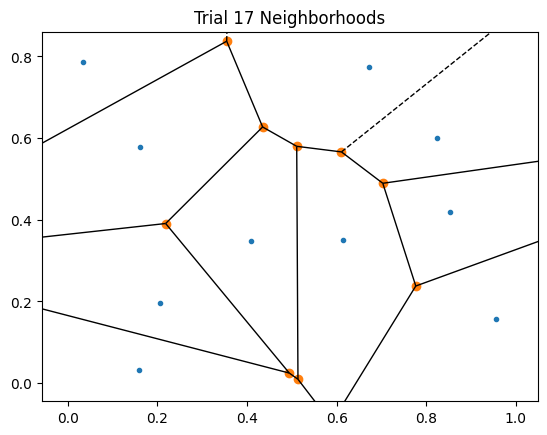

In [9]:
for t_id in sorted(np.unique(data_trials["trial_index"]).astype(int)):
    # Filter for the trial and get the first row safely
    trial_subset = data_trials[(data_trials['trial_index'] == str(t_id)) & (~data_trials['trial_type'].isin(['SimRI', 'DivRI', 'D']))]
    if trial_subset['neighborhood_areas'].empty:
        continue
    fig = voronoi_plot_2d(trial_subset['neighborhood_areas'].iloc[0])
    plt.title(f"Trial {t_id} Neighborhoods")
    plt.show()

### Plot correct placements

In [10]:
data_clean = data_trials.dropna(subset=["n_correct"])
plot_df = (data_clean.groupby(["ID", "group", "trial_type"], as_index=False).agg(mean_correct=("n_correct", "mean"), NLV=("NLV_Filled", "first"),IF_Stroop=("IF_Stroop_Predicted", "first")))

plot_df["trial type label"] = plot_df["trial_type"].map(condition_labels)
plot_df["trial type label"] = pd.Categorical(plot_df["trial type label"],categories=[condition_labels[c] for c in condition_order], ordered=True)


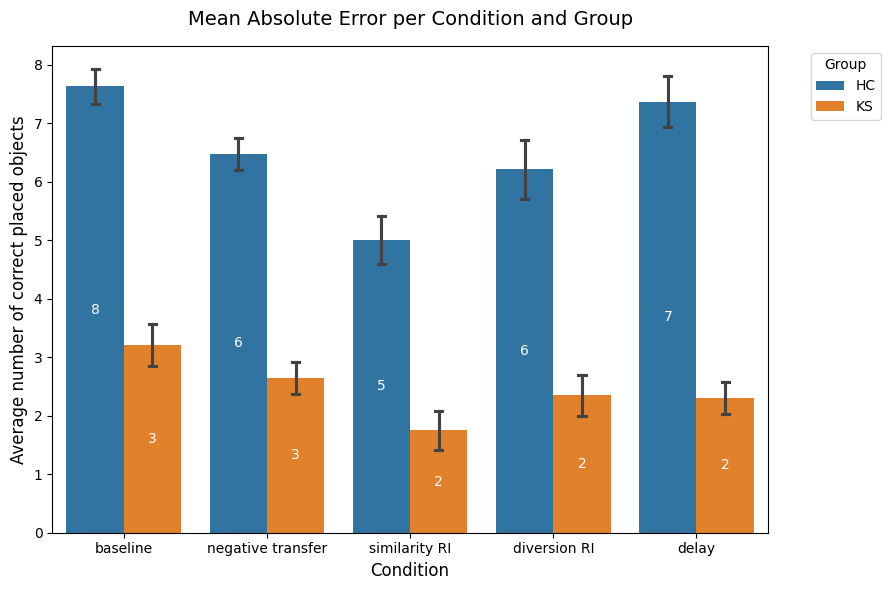

In [11]:
plt.figure(figsize=(9, 6))
ax = sns.barplot(data=plot_df, x="trial type label", y="mean_correct",hue="group", errorbar="se", capsize=0.1,linewidth=1)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='center', fontsize=10, color='white')

plt.ylabel("Average number of correct placed objects", fontsize=12)
plt.xlabel("Condition", fontsize=12)
plt.title("Mean Absolute Error per Condition and Group", fontsize=14, pad=15)
plt.legend(title="Group", bbox_to_anchor=(1.05, 1), loc='upper left')
#plt.ylim(0, 10)
plt.tight_layout()
plt.show()

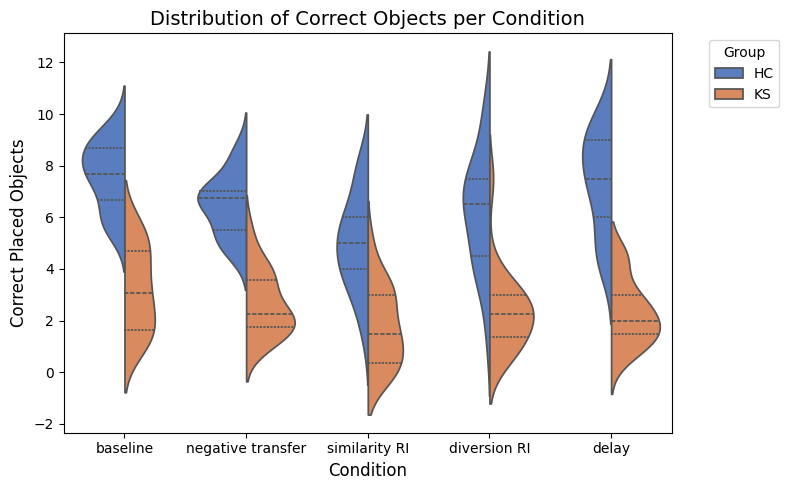

In [17]:
plt.figure(figsize=(8, 5))

# Use the non-aggregated data to show the full distribution
sns.violinplot(
    data=plot_df,
    x="trial type label",
    y="mean_correct",
    hue="group",
    split=True,      # Merges the two groups into one violin
    inner="quart",   # Shows the median and quartiles inside
    palette="muted"
)

plt.ylabel("Correct Placed Objects", fontsize=12)
plt.xlabel("Condition", fontsize=12)
plt.title("Distribution of Correct Objects per Condition", fontsize=14)
plt.legend(title="Group", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

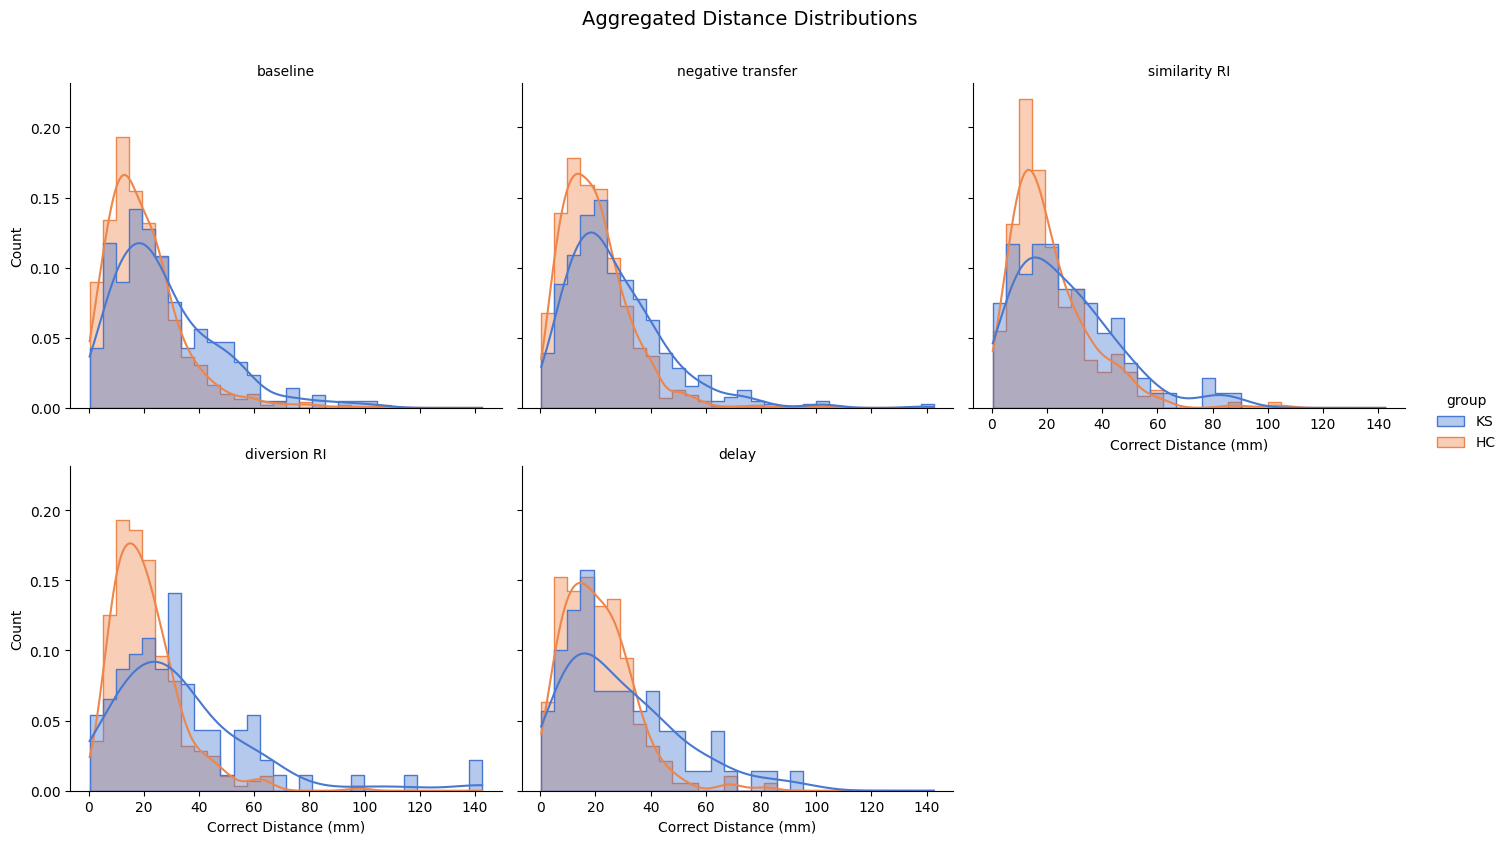

In [45]:
data_clean = data_trials.dropna(subset=["correct_distance_mm"])
plot_df_dist = data_clean.explode("correct_distance_mm")
plot_df_dist = plot_df_dist.reset_index(drop=True) 

# 2. Ensure numeric
plot_df_dist["correct_distance_mm"] = pd.to_numeric(plot_df_dist["correct_distance_mm"])

# 3. Map condition labels
plot_df_dist["trial type label"] = plot_df_dist["trial_type"].map(condition_labels)
plot_df_dist["trial type label"] = pd.Categorical(
    plot_df_dist["trial type label"],
    categories=[condition_labels[c] for c in condition_order],
    ordered=True
)

# 4. Plot (This should now run without the Reindex error)
g = sns.displot(
    data=plot_df_dist,
    x="correct_distance_mm",
    hue="group",
    col="trial type label",
    kind="hist",
    stat="probability",   
    common_norm=False,
    kde=True,
    bins=30,
    element="step",
    palette="muted",
    alpha=0.4,
    common_bins=True,
    col_wrap=3,
    height=4,
    aspect=1.2
)

g.set_axis_labels("Correct Distance (mm)", "Count")
g.set_titles("{col_name}")
g.fig.suptitle("Aggregated Distance Distributions", y=1.05, fontsize=14)

plt.show()

In [ ]:
# 1. Prepare data (Explode and Reset Index to avoid reindex errors)
data_clean = data_trials.dropna(subset=["correct_distance_mm"])
plot_df_dist = data_clean.explode("correct_distance_mm").reset_index(drop=True)
plot_df_dist["correct_distance_mm"] = pd.to_numeric(plot_df_dist["correct_distance_mm"])

# 2. Map condition labels
plot_df_dist["trial type label"] = plot_df_dist["trial_type"].map(condition_labels)
plot_df_dist["trial type label"] = pd.Categorical(
    plot_df_dist["trial type label"],
    categories=[condition_labels[c] for c in condition_order],
    ordered=True
)

# 3. Plot the ECDF (Cumulative Distribution)
g = sns.displot(
    data=plot_df_dist,
    x="correct_distance_mm",
    hue="group",
    col="trial type label",
    kind="ecdf",         # Changed from "hist" to "ecdf"
    palette="muted",
    linewidth=2.5,       # Thicker lines make it easier to see the steps
    col_wrap=3,
    height=4,
    aspect=1.2
)

# 4. Styling and labels
g.set_axis_labels("Correct Distance (mm)", "Proportion (Cumulative)")
g.set_titles("{col_name}")

# Optional: Add a grid to make it easier to read percentiles
for ax in g.axes.flat:
    ax.grid(True, which='both', linestyle='--', alpha=0.5)

g.fig.suptitle("Cumulative Distribution of Distances by Condition", y=1.05, fontsize=14)

plt.show()

### Plot error placements

In [39]:
data_clean = data_trials.copy()
data_clean["trial type label"] = data_clean["trial_type"].map(condition_labels)
data_clean["trial type label"] = pd.Categorical(data_clean["trial type label"],categories=[condition_labels[c] for c in condition_order], ordered=True)

agg_df = (data_clean.groupby(["trial type label", "group"]).agg(mean_swaps=("n_swaps", "mean"),
                                                                mean_subs=("n_substitutions", "mean"),
                                                                se_swaps=("n_swaps", "sem"),
                                                                se_subs=("n_substitutions", "sem")).reset_index())

# Total errors
agg_df["mean_errors"] = agg_df["mean_swaps"] + agg_df["mean_subs"]
agg_df["se_errors"] = np.sqrt(agg_df["se_swaps"]**2 + agg_df["se_subs"]**2)

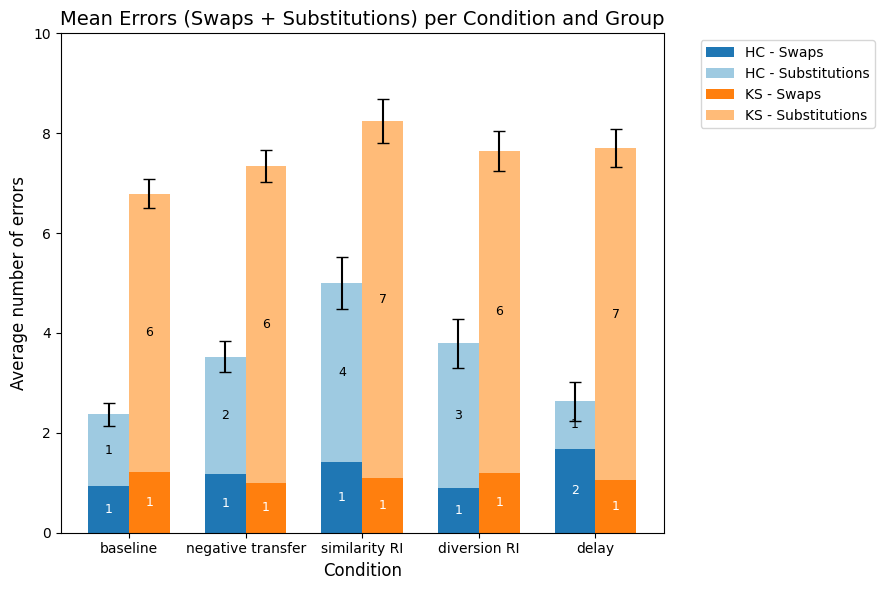

In [40]:
plt.figure(figsize=(9, 6))

conditions = agg_df["trial type label"].unique()
groups = agg_df["group"].unique()

x = np.arange(len(conditions))
width = 0.35
colors = {"HC": {"swaps": "#1f77b4", "subs": "#9ecae1"},"KS": {"swaps": "#ff7f0e", "subs": "#ffbb78"}}

for i, group in enumerate(groups):

    subset = agg_df[agg_df["group"] == group]
    offsets = x + (i - (len(groups)-1)/2) * width

    swaps = subset["mean_swaps"].values
    subs = subset["mean_subs"].values
    totals = subset["mean_errors"].values

    # Swaps (bottom)
    bars_swaps = plt.bar(offsets,swaps,width,color=colors[group]["swaps"],label=f"{group} - Swaps")

    # Substitutions (top)
    bars_subs = plt.bar(offsets, subs,width,bottom=swaps,color=colors[group]["subs"],label=f"{group} - Substitutions")

    # Add centered text labels
    for j in range(len(offsets)):
        if swaps[j] > 0: # Swaps label
            plt.text(offsets[j],swaps[j] / 2,f"{swaps[j]:.0f}", ha="center", va="center", fontsize=9,color="white")
        if subs[j] > 0: # Substitutions label
            plt.text(offsets[j],swaps[j] + subs[j] / 2, f"{subs[j]:.0f}",ha="center",va="center",fontsize=9,color="black")
nd posters on mental imagery and spatial cognition. Other topics of interest to EWIC include (among others) are perception, attention, memory, emotion, time, language, ageing, new technologies and Virtual Reality and more!
    # --- Error bars (total height)
    plt.errorbar(offsets,totals,yerr=subset["se_errors"],fmt="none",capsize=4,color="black")

plt.xticks(x, conditions)
plt.ylabel("Average number of errors", fontsize=12)
plt.xlabel("Condition", fontsize=12)
plt.title("Mean Errors (Swaps + Substitutions) per Condition and Group", fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.ylim(0, 10)
plt.tight_layout()
plt.show()

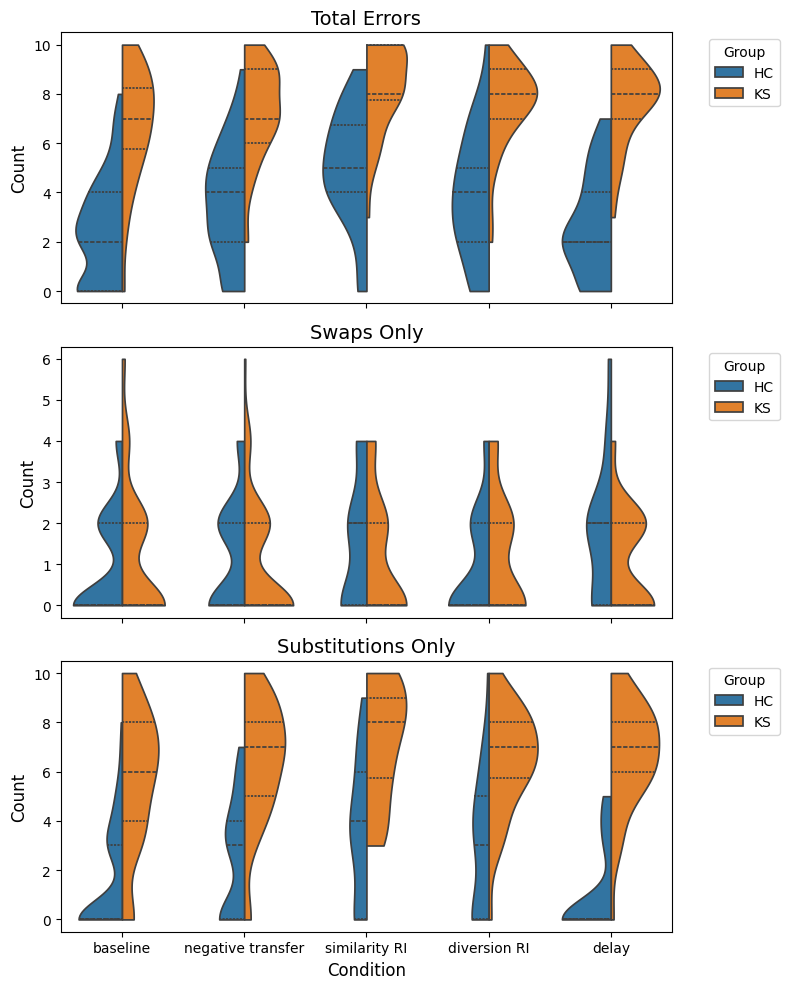

In [41]:
data_clean["total_errors"] = data_clean["n_swaps"] + data_clean["n_substitutions"]
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

error_types = ["total_errors", "n_swaps", "n_substitutions"]
titles = ["Total Errors", "Swaps Only", "Substitutions Only"]
group_order = ["HC", "KS"]

for i, error in enumerate(error_types):
    sns.violinplot(
        data=data_clean,
        x="trial type label",
        y=error,
        hue="group",
        hue_order=group_order,
        split=True,
        inner="quart",
        cut=0,
        ax=axes[i]
    )
    axes[i].set_title(titles[i], fontsize=14)
    axes[i].set_ylabel("Count", fontsize=12)
    axes[i].legend(title="Group", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xlabel("Condition", fontsize=12)
plt.tight_layout()
plt.show()

In [42]:
data_trials.columns

Index(['trial_index', 'trial_type', 'number_objects', 'encoding_time_(ms)',
       'absolute_error_score', 'bestfit_score', 'final_time_(ms)',
       'permutations', 'n_correct', 'n_swaps', 'n_substitutions', 'n_errors',
       'correct_distance_mm', 'swap_distance_mm', 'substitution_distance_mm',
       'error_distance_mm', 'repetitions', 'neighborhood_areas', 'run', 'ID',
       'group', 'NLV', 'IF_Stroop', 'NLV_Filled', 'IF_Stroop_Predicted'],
      dtype='str')

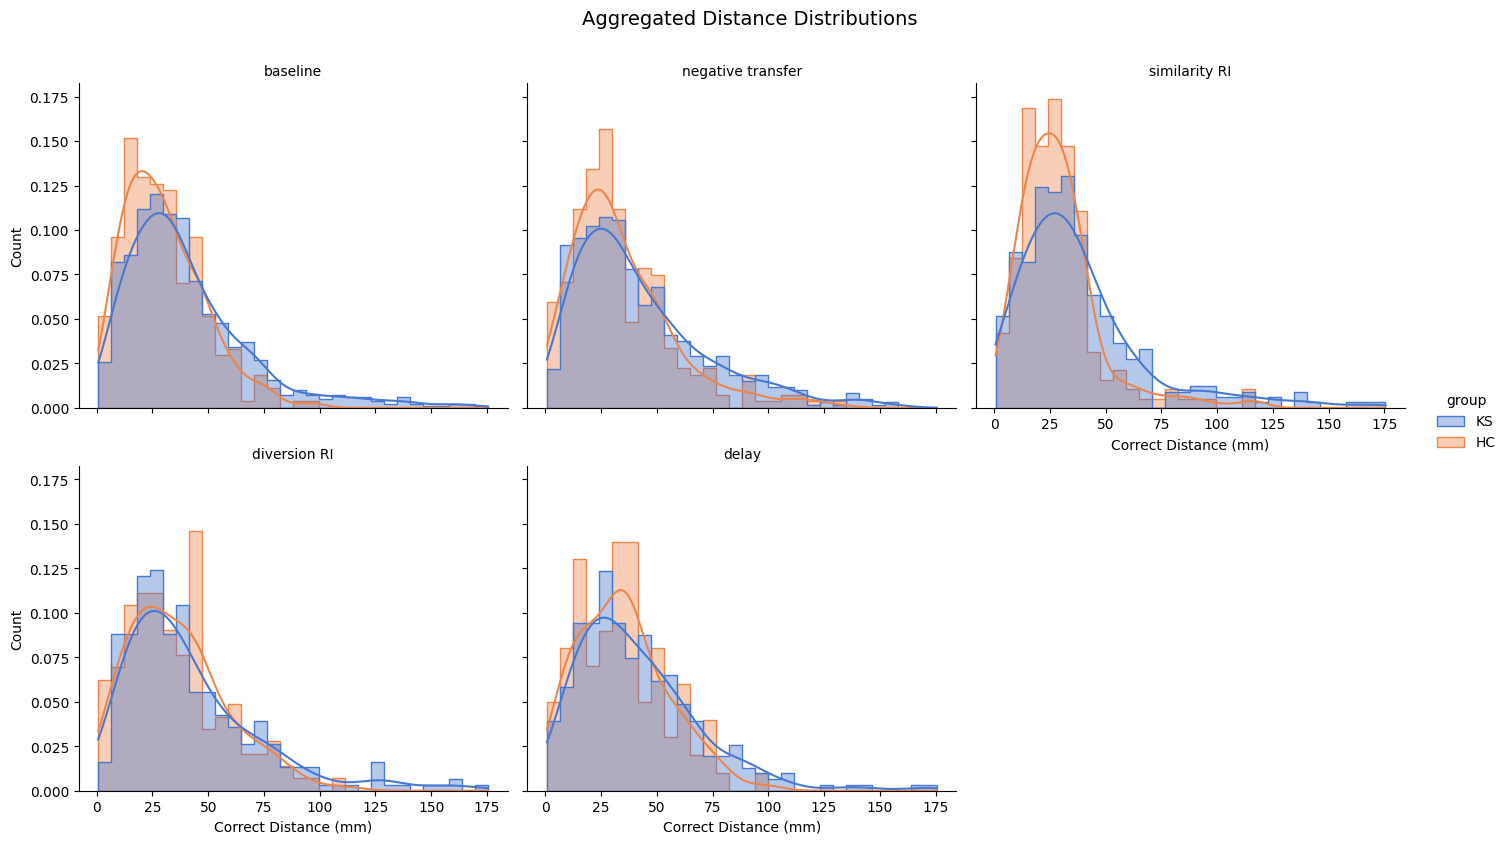

In [47]:
data_clean = data_trials.dropna(subset=["error_distance_mm"])
plot_df_dist = data_clean.explode("error_distance_mm")
plot_df_dist = plot_df_dist.reset_index(drop=True) 

# 2. Ensure numeric
plot_df_dist["error_distance_mm"] = pd.to_numeric(plot_df_dist["error_distance_mm"])

# 3. Map condition labels
plot_df_dist["trial type label"] = plot_df_dist["trial_type"].map(condition_labels)
plot_df_dist["trial type label"] = pd.Categorical(
    plot_df_dist["trial type label"],
    categories=[condition_labels[c] for c in condition_order],
    ordered=True
)

# 4. Plot (This should now run without the Reindex error)
g = sns.displot(
    data=plot_df_dist,
    x="error_distance_mm",
    hue="group",
    col="trial type label",
    kind="hist",
    stat="probability",   
    common_norm=False,
    kde=True,
    element="step",
    palette="muted",
    alpha=0.4,
    common_bins=True,
    col_wrap=3,
    height=4,
    bins=30,
    aspect=1.2
)

g.set_axis_labels("Correct Distance (mm)", "Count")
g.set_titles("{col_name}")
g.fig.suptitle("Aggregated Distance Distributions", y=1.05, fontsize=14)

plt.show()

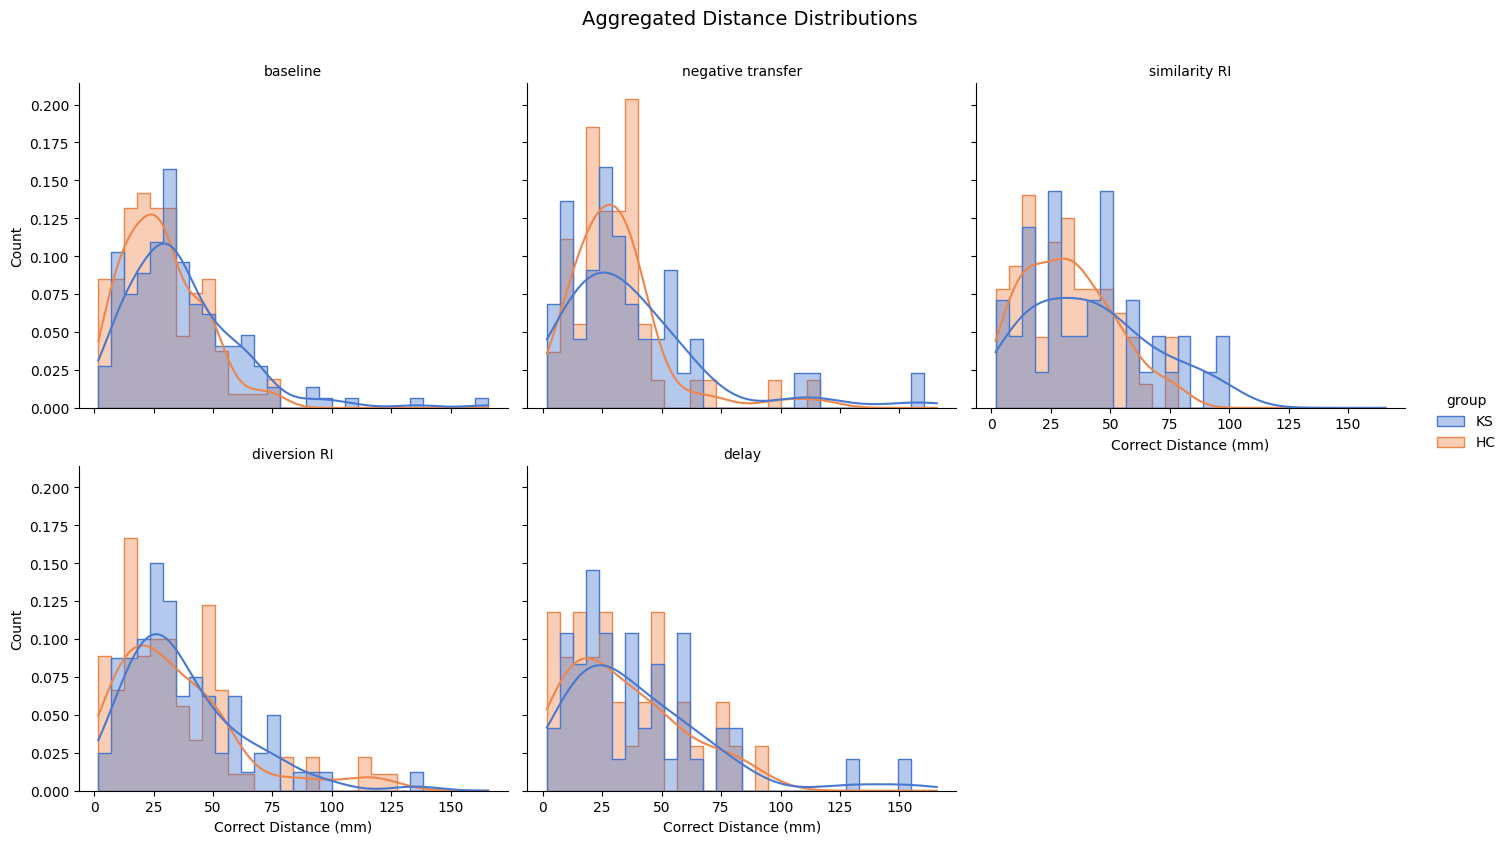

In [48]:
data_clean = data_trials.dropna(subset=["swap_distance_mm"])
plot_df_dist = data_clean.explode("swap_distance_mm")
plot_df_dist = plot_df_dist.reset_index(drop=True) 

# 2. Ensure numeric
plot_df_dist["swap_distance_mm"] = pd.to_numeric(plot_df_dist["swap_distance_mm"])

# 3. Map condition labels
plot_df_dist["trial type label"] = plot_df_dist["trial_type"].map(condition_labels)
plot_df_dist["trial type label"] = pd.Categorical(
    plot_df_dist["trial type label"],
    categories=[condition_labels[c] for c in condition_order],
    ordered=True
)

# 4. Plot (This should now run without the Reindex error)
g = sns.displot(
    data=plot_df_dist,
    x="swap_distance_mm",
    hue="group",
    col="trial type label",
    kind="hist",
    stat="probability",   
    common_norm=False,
    kde=True,
    element="step",
    palette="muted",
    alpha=0.4,
    common_bins=True,
    col_wrap=3,
    height=4,
    bins=30,
    aspect=1.2
)

g.set_axis_labels("Correct Distance (mm)", "Count")
g.set_titles("{col_name}")
g.fig.suptitle("Aggregated Distance Distributions", y=1.05, fontsize=14)

plt.show()

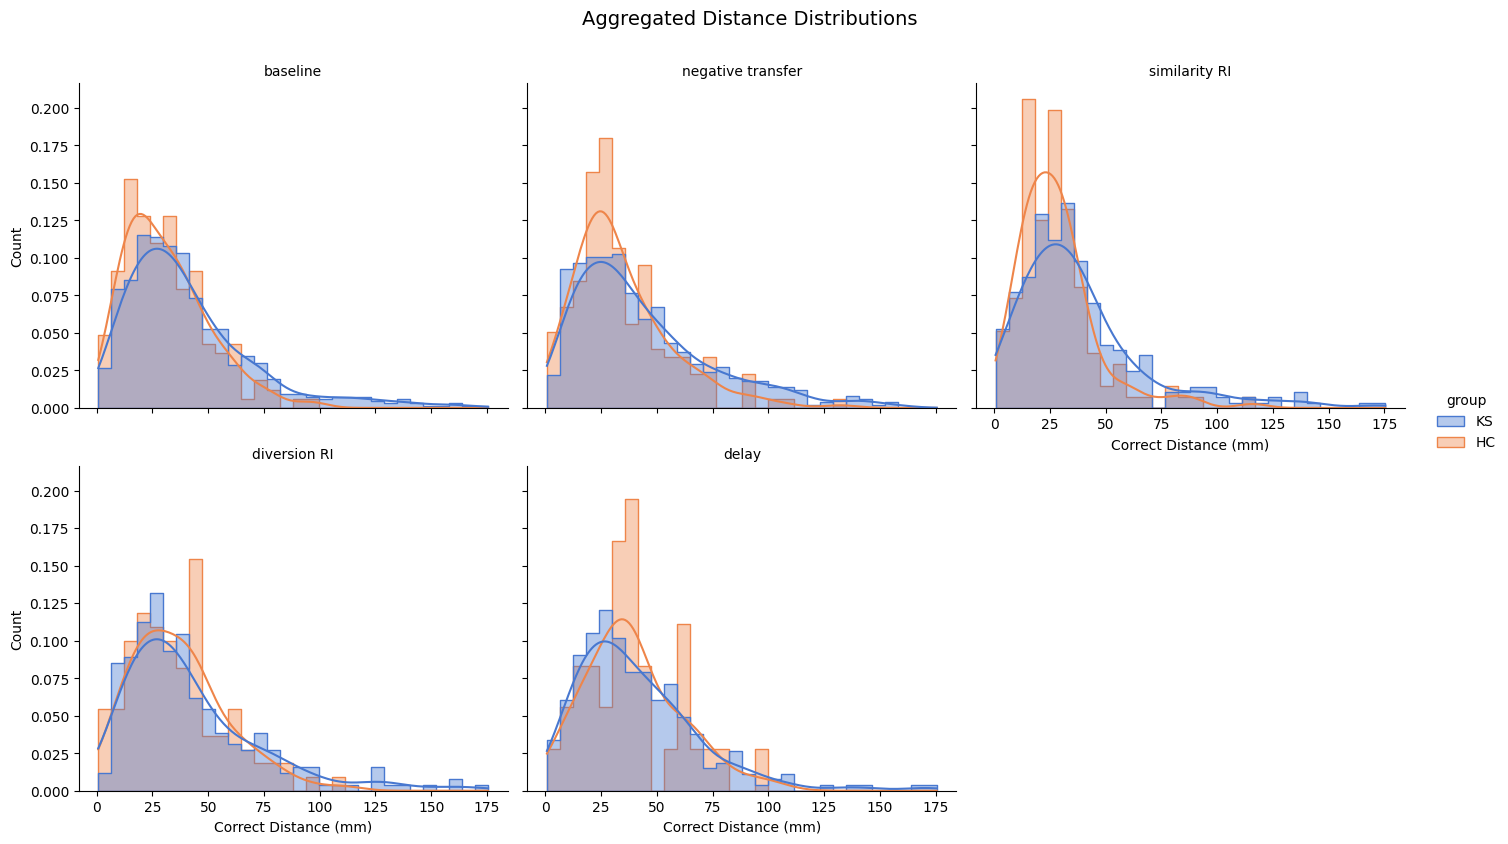

In [49]:
data_clean = data_trials.dropna(subset=["substitution_distance_mm"])
plot_df_dist = data_clean.explode("substitution_distance_mm")
plot_df_dist = plot_df_dist.reset_index(drop=True) 

# 2. Ensure numeric
plot_df_dist["substitution_distance_mm"] = pd.to_numeric(plot_df_dist["substitution_distance_mm"])

# 3. Map condition labels
plot_df_dist["trial type label"] = plot_df_dist["trial_type"].map(condition_labels)
plot_df_dist["trial type label"] = pd.Categorical(
    plot_df_dist["trial type label"],
    categories=[condition_labels[c] for c in condition_order],
    ordered=True
)

# 4. Plot (This should now run without the Reindex error)
g = sns.displot(
    data=plot_df_dist,
    x="substitution_distance_mm",
    hue="group",
    col="trial type label",
    kind="hist",
    stat="probability",   
    common_norm=False,
    kde=True,
    element="step",
    palette="muted",
    alpha=0.4,
    common_bins=True,
    col_wrap=3,
    height=4,
    bins=30,
    aspect=1.2
)

g.set_axis_labels("Correct Distance (mm)", "Count")
g.set_titles("{col_name}")
g.fig.suptitle("Aggregated Distance Distributions", y=1.05, fontsize=14)

plt.show()